# Reproducing Meta-RL Learning Curves on HalfCheetahVel

## VariBAD, MAML, and RL2

> **You may change, replace, split, merge, reorder, or delete any cell in this notebook.**
>
> The provided structure is only a starting point. Your implementation may use different classes,
> helper functions, optimizers, data structures, or training loops, provided that you satisfy the
> experimental protocol and clearly document every departure from the papers.

Your goal is to implement three meta-reinforcement-learning algorithms in **PyTorch**, using the
papers as the primary specifications:

1. **VariBAD**
2. **MAML for reinforcement learning**
3. **RL2**

You will then reproduce the result in **Figures 4 and 6** of the VariBAD paper for the **HalfCheetahVel** task.


## Required papers

Read the papers before implementing the methods.

### VariBAD

**Zintgraf et al., "VariBAD: A Very Good Method for Bayes-Adaptive Deep RL via Meta-Learning," ICLR 2020**

- Paper: https://arxiv.org/abs/1910.08348

### RL2

**Duan et al., "RL2: Fast Reinforcement Learning via Slow Reinforcement Learning," 2016**

- Paper: https://arxiv.org/abs/1611.02779

### MAML

**Finn, Abbeel, and Levine, "Model-Agnostic Meta-Learning for Fast Adaptation of Deep Networks," ICML 2017**

- Paper: https://arxiv.org/abs/1703.03400

### Important difference

The published VariBAD Figure 6 compares against **E-MAML**, not plain MAML. This project asks
you to implement **vanilla MAML** from the MAML paper.


### Figure 4 reproduction note

The published Figure 4 reports **average meta-test return over the first five rollouts** for each
MuJoCo environment. In this notebook, reproduce only the **HalfCheetahVel** panel and compare the
three required implementations: VariBAD, RL2, and vanilla MAML.

As with Figure 6, this is not an exact method-for-method reproduction of the published panel because
the paper reports **E-MAML**, while this project requires **vanilla MAML**. Clearly label the
result as a Figure 4-style HalfCheetahVel reproduction.


## Learning objectives

By completing this project, you should be able to:

- distinguish optimization-based, recurrent, and inference-based meta-RL;
- implement a hidden-task continuous-control benchmark;
- separate meta-training tasks from held-out meta-test tasks;
- implement within-task adaptation without leaking the task identity.


## HalfCheetahVel protocol

Each task is defined by a hidden target velocity $v^\star$. The agent observes the standard
HalfCheetah state but **does not observe $v^\star$**.

At each time step, use

$$
r_t = -\left|v_t-v^\star\right| - 0.05\lVert a_t\rVert_2^2,
$$

where $v_t$ is the forward velocity and $a_t$ is the action.

### Required benchmark settings

- Target velocities are sampled from $[0,3]$.
- One MDP episode has horizon $H=200$.
- VariBAD and RL2 are trained on two consecutive episodes of the same task:
  $$
  H^+ = 2H = 400.
  $$
- The physical environment resets after the first episode, but:
  - RL2 must preserve its recurrent hidden state;
  - VariBAD must preserve its inferred task posterior;
  - a done/reset indicator must be made available to recurrent inference.
- MAML adapts through gradient updates computed from support trajectories and is evaluated on a
  fresh query trajectory.
- Meta-test tasks must not be used for gradient updates during meta-training.
- The target velocity or task ID must never be passed directly to the policy, encoder, critic, or
  value function.


## What must be submitted

1. This completed notebook.
2. Implementations of VariBAD, MAML, and RL2.
3. Training curves.

You may checkpoint models during training, but the final plots must be generated by code in this
notebook.


### Required figure outputs

The completed notebook must generate both of the following for **HalfCheetahVel only**:

1. A **Figure 6-style** two-panel learning-curve plot versus meta-training environment frames,
   showing first-rollout and adapted/method-specific final-rollout return.
2. A **Figure 4-style** plot showing average test return for rollouts 1 through 5 at the selected
   final checkpoint.

Both figures must be generated from the actual trained models, not from manually entered values.


In [1]:
# Colab setup.
# Run this cell once in a fresh runtime, then restart the runtime only if Colab requests it.

%pip install -q "gymnasium[mujoco]>=1.0,<2" "mujoco>=3.2,<4" \
    "numpy>=1.24" "pandas>=2.0" "matplotlib>=3.7" "tqdm>=4.66"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.7/232.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.9/18.9 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 8.3 MB/s eta 0:00:00


In [2]:
# Imports used by the implementations below.

import copy
import math
import os
import random
import time
from collections import OrderedDict
from dataclasses import asdict, dataclass
from typing import Any, Dict, List, Mapping, Optional, Sequence, Tuple

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
from tqdm.auto import tqdm

try:
    from torch.func import functional_call
except ImportError:  # compatibility with older PyTorch releases
    from torch.nn.utils.stateless import functional_call


In [3]:
@dataclass
class ExperimentConfig:
    # Environment and task distribution
    env_id: str = "HalfCheetah-v5"
    velocity_low: float = 0.0
    velocity_high: float = 3.0
    episode_horizon: int = 200
    recurrent_rollouts_per_task: int = 2

    # Task splits
    num_train_tasks: int = 100
    num_validation_tasks: int = 20
    num_test_tasks: int = 30
    task_split_seed: int = 2026

    # Full reproduction target
    total_frames: int = 100_000_000
    evaluation_interval_frames: int = 1_000_000
    evaluation_tasks: int = 30
    evaluation_episodes_per_task: int = 1
    seeds: Tuple[int, ...] = (11, 22, 33, 44, 55)

    # Shared RL defaults. Each method may override these.
    gamma: float = 0.97
    gae_lambda: float = 0.90
    max_grad_norm: float = 0.5

    # Logging
    verbose_interval_updates: int = 10


FULL_CONFIG = ExperimentConfig()

# A small configuration for debugging interfaces only.
DEBUG_CONFIG = ExperimentConfig(
    num_train_tasks=8,
    num_validation_tasks=4,
    num_test_tasks=4,
    total_frames=20_000,
    evaluation_interval_frames=5_000,
    evaluation_tasks=4,
    seeds=(0,),
)

# Change this during development.
MEDIUM_CONFIG = ExperimentConfig(
    num_train_tasks=40,
    num_validation_tasks=10,
    num_test_tasks=10,
    total_frames=500_000,
    evaluation_interval_frames=50_000,
    evaluation_tasks=10,
    seeds=(0,),
)

CONFIG = MEDIUM_CONFIG

print(asdict(CONFIG))

{'env_id': 'HalfCheetah-v5', 'velocity_low': 0.0, 'velocity_high': 3.0, 'episode_horizon': 200, 'recurrent_rollouts_per_task': 2, 'num_train_tasks': 40, 'num_validation_tasks': 10, 'num_test_tasks': 10, 'task_split_seed': 2026, 'total_frames': 500000, 'evaluation_interval_frames': 50000, 'evaluation_tasks': 10, 'evaluation_episodes_per_task': 1, 'seeds': (0,), 'gamma': 0.97, 'gae_lambda': 0.9, 'max_grad_norm': 0.5, 'verbose_interval_updates': 10}


In [4]:
# Figure 4 evaluates five consecutive meta-test rollouts at the selected checkpoint.
# This is kept separate from the existing configuration fields so the original
# experiment configuration remains unchanged.
FIGURE4_EVALUATION_ROLLOUTS: int = 5


In [5]:
def seed_everything(seed: int) -> None:
    """Seed Python, NumPy, and PyTorch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


## Provided environment infrastructure

The following wrapper defines the common benchmark. You may modify its implementation, but all
methods must ultimately be evaluated with the same reward, task split, horizon, and observation
semantics.

The standard Gymnasium HalfCheetah observation does not expose the global torso $x$-position.
The wrapper recomputes the reward using the hidden target velocity.


In [6]:
class HalfCheetahVel(gym.Wrapper):
    """HalfCheetah with a hidden target-velocity task."""

    def __init__(
        self,
        target_velocity: float,
        env_id: str = "HalfCheetah-v5",
        horizon: int = 200,
        render_mode: Optional[str] = None,
    ):
        base_env = gym.make(
            env_id,
            render_mode=render_mode,
            max_episode_steps=horizon,
        )
        super().__init__(base_env)
        self.target_velocity = float(target_velocity)
        self.horizon = int(horizon)
        self._elapsed_steps_local = 0

    @property
    def task(self) -> Dict[str, float]:
        # This property is for experiment control and logging only.
        # Do not feed it to an agent.
        return {"velocity": self.target_velocity}

    def reset(
        self,
        *,
        seed: Optional[int] = None,
        options: Optional[dict] = None,
    ):
        self._elapsed_steps_local = 0
        obs, info = self.env.reset(seed=seed, options=options)
        info = dict(info)
        info["task_velocity_for_logging_only"] = self.target_velocity
        return obs.astype(np.float32), info

    def step(self, action):
        x_before = float(self.unwrapped.data.qpos[0])
        _, _, terminated, truncated, info = self.env.step(action)
        x_after = float(self.unwrapped.data.qpos[0])

        forward_velocity = (x_after - x_before) / float(self.unwrapped.dt)
        velocity_reward = -abs(forward_velocity - self.target_velocity)
        control_cost = 0.05 * float(np.square(action).sum())
        reward = velocity_reward - control_cost

        self._elapsed_steps_local += 1
        obs = self.unwrapped._get_obs().astype(np.float32)

        info = dict(info)
        info.update(
            {
                "forward_velocity": forward_velocity,
                "velocity_error": forward_velocity - self.target_velocity,
                "reward_velocity": velocity_reward,
                "reward_control": -control_cost,
                "task_velocity_for_logging_only": self.target_velocity,
            }
        )
        return obs, float(reward), bool(terminated), bool(truncated), info

In [7]:
@dataclass(frozen=True)
class TaskSplits:
    train: np.ndarray
    validation: np.ndarray
    test: np.ndarray


def make_task_splits(config: ExperimentConfig) -> TaskSplits:
    """Create deterministic, disjoint finite task sets."""
    rng = np.random.default_rng(config.task_split_seed)
    total = config.num_train_tasks + config.num_validation_tasks + config.num_test_tasks
    velocities = rng.uniform(
        config.velocity_low,
        config.velocity_high,
        size=total,
    ).astype(np.float32)

    n_train = config.num_train_tasks
    n_val = config.num_validation_tasks

    return TaskSplits(
        train=velocities[:n_train],
        validation=velocities[n_train:n_train + n_val],
        test=velocities[n_train + n_val:],
    )


TASKS = make_task_splits(CONFIG)
print("Training tasks:", TASKS.train)
print("Validation tasks:", TASKS.validation)
print("Test tasks:", TASKS.test)

Training tasks: [0.53680444 1.9197395  1.4018052  1.1115016  1.064752   2.3715549
 2.7154315  0.53205955 1.9583544  0.8949083  2.9008865  2.7595506
 1.9076124  2.2581964  1.545461   2.4776857  1.3451416  1.0164374
 0.8336976  0.6789992  1.5774505  1.2927362  1.9895419  0.03852145
 1.3431057  1.0955424  0.5861928  1.7845976  1.3059394  0.8999745
 0.62824833 2.6238723  2.392387   1.820129   1.0353017  2.8404593
 1.6901321  1.2982882  2.7013488  0.9580254 ]
Validation tasks: [2.0879846  0.94146097 0.78465915 2.1025226  0.68367594 1.479331
 1.7400854  0.5667191  2.193722   1.6454492 ]
Test tasks: [1.8645098  1.1164329  1.2605798  1.4844891  1.4099127  2.0269177
 1.7315325  1.248812   0.00540706 2.3820932 ]


In [8]:
# Environment smoke test

seed_everything(0)
test_env = HalfCheetahVel(
    target_velocity=float(TASKS.train[0]),
    env_id=CONFIG.env_id,
    horizon=CONFIG.episode_horizon,
)
obs, info = test_env.reset(seed=0)
action = test_env.action_space.sample()
next_obs, reward, terminated, truncated, info = test_env.step(action)

print("Observation shape:", obs.shape)
print("Action shape:", action.shape)
print("One-step reward:", reward)
print("Forward velocity:", info["forward_velocity"])
print("Target velocity:", info["task_velocity_for_logging_only"])

assert obs.ndim == 1
assert next_obs.shape == obs.shape
assert np.isfinite(reward)
test_env.close()

Observation shape: (17,)
Action shape: (6,)
One-step reward: -0.1161208685714515
Forward velocity: 0.49036701952631156
Target velocity: 0.5368044376373291


## Common result contract

You may organize training however you want, but each completed run must be converted to the
following in-memory format so that the provided plotting tools can compare methods.

```python
history = {
    "method": "VariBAD",               # or "RL2", "MAML"
    "seed": 11,
    "frames": np.ndarray,              # shape [K], monotonically increasing
    "first_rollout_return": np.ndarray,# shape [K]
    "adapted_return": np.ndarray,      # shape [K]
    "metadata": {...},                 # hyperparameters and protocol
}
```

Interpretation:

- `first_rollout_return`: mean return on the first episode of held-out tasks, before useful
  task-specific information is available.
- `adapted_return`:
  - VariBAD: second rollout while retaining the posterior;
  - RL2: second rollout while retaining the recurrent state;
  - MAML: query rollout after the declared support-set gradient adaptation.

All evaluation must use the same fixed held-out task set for a given seed and checkpoint.


### Figure 4 result contract

The Figure 4-style evaluation requires per-seed, per-task, per-rollout returns at the selected final
checkpoint. Store them as:

```python
figure4_rollout_results = {
    "VariBAD": np.ndarray,  # [num_seeds, num_test_tasks, 5]
    "RL2": np.ndarray,      # [num_seeds, num_test_tasks, 5]
    "MAML": np.ndarray,     # [num_seeds, num_test_tasks, 5]
}
```

For VariBAD and RL2, do not reset adaptation state between the five rollouts of a task. For MAML,
retain only the task-specific fast parameters between rollouts and reset them to the learned
meta-initialization when moving to a new task. Preserve the individual task dimension until after all
evaluation data have been collected.


In [9]:
def validate_history(history: Mapping[str, Any]) -> None:
    """Validate the output format expected by the plotting utilities."""
    required = {
        "method",
        "seed",
        "frames",
        "first_rollout_return",
        "adapted_return",
        "metadata",
    }
    missing = required.difference(history.keys())
    if missing:
        raise KeyError(f"History is missing keys: {sorted(missing)}")

    frames = np.asarray(history["frames"], dtype=np.float64)
    first = np.asarray(history["first_rollout_return"], dtype=np.float64)
    adapted = np.asarray(history["adapted_return"], dtype=np.float64)

    if not (frames.ndim == first.ndim == adapted.ndim == 1):
        raise ValueError("frames and return arrays must all be one-dimensional.")
    if not (len(frames) == len(first) == len(adapted)):
        raise ValueError("frames and return arrays must have equal lengths.")
    if len(frames) == 0:
        raise ValueError("history may not be empty.")
    if np.any(np.diff(frames) <= 0):
        raise ValueError("frames must be strictly increasing.")
    if not np.all(np.isfinite(first)) or not np.all(np.isfinite(adapted)):
        raise ValueError("Return arrays contain non-finite values.")

# Part I - Shared reinforcement-learning infrastructure

You will probably need:

- a diagonal Gaussian policy for continuous actions;
- correct action scaling or clipping;
- log-probabilities under the behavior policy;
- a value function;
- trajectory storage;
- return and advantage computation;
- generalized advantage estimation;
- an on-policy optimizer such as PPO or TRPO;
- checkpoint and evaluation utilities;
- careful treatment of time-limit truncation.

These helpers may be shared across methods. Do not accidentally detach tensors needed by MAML's
meta-gradient, and do not shuffle recurrent sequences in a way that destroys temporal order.


In [10]:
@dataclass
class TrajectoryBatch:
    """
    Feed-forward trajectory data.

    Tensor shapes:
        observations:      [T, obs_dim]
        actions:           [T, act_dim]
        rewards:           [T]
        next_observations: [T, obs_dim]
        terminated:        [T] bool
        truncated:         [T] bool
        dones_for_agent:   [T] bool (terminated OR truncated)
        log_probs:         [T] or None
        values:            [T] or None
        returns:           [T] or None
        advantages:        [T] or None
    """
    observations: torch.Tensor
    actions: torch.Tensor
    rewards: torch.Tensor
    next_observations: torch.Tensor
    terminated: torch.Tensor
    truncated: torch.Tensor
    dones_for_agent: torch.Tensor
    log_probs: Optional[torch.Tensor] = None
    values: Optional[torch.Tensor] = None
    returns: Optional[torch.Tensor] = None
    advantages: Optional[torch.Tensor] = None


class SquashedDiagGaussian:
    """Diagonal Gaussian followed by tanh, with the exact change-of-variables log-probability."""

    def __init__(self, mean: torch.Tensor, log_std: torch.Tensor):
        self.loc = mean
        self.log_std = torch.clamp(log_std, -5.0, 2.0)
        self.scale = self.log_std.exp()
        self.base = Normal(self.loc, self.scale)

    @property
    def mean(self) -> torch.Tensor:
        return torch.tanh(self.loc)

    def rsample(self) -> torch.Tensor:
        return torch.tanh(self.base.rsample())

    def sample(self) -> torch.Tensor:
        return torch.tanh(self.base.sample())

    def log_prob(self, action: torch.Tensor) -> torch.Tensor:
        eps = 1e-6
        action = torch.clamp(action, -1.0 + eps, 1.0 - eps)
        pre_tanh = 0.5 * (torch.log1p(action) - torch.log1p(-action))
        log_base = self.base.log_prob(pre_tanh)
        correction = torch.log(torch.clamp(1.0 - action.pow(2), min=eps))
        return (log_base - correction).sum(dim=-1)

    def entropy(self) -> torch.Tensor:
        # The exact entropy after tanh has no closed form. The base-Gaussian entropy
        # is a standard, stable exploration proxy for PPO/PG regularization.
        return self.base.entropy().sum(dim=-1)


def build_mlp(
    input_dim: int,
    hidden_sizes: Sequence[int],
    output_dim: int,
    activation: type[nn.Module] = nn.Tanh,
) -> nn.Sequential:
    layers: List[nn.Module] = []
    d = int(input_dim)
    for h in hidden_sizes:
        layers.extend([nn.Linear(d, int(h)), activation()])
        d = int(h)
    layers.append(nn.Linear(d, int(output_dim)))
    return nn.Sequential(*layers)


def compute_returns_and_advantages(
    rewards: torch.Tensor,
    values: torch.Tensor,
    terminated: torch.Tensor,
    truncated: torch.Tensor,
    gamma: float,
    gae_lambda: float,
    bootstrap_value: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Compute GAE(lambda) for one ordered environment episode.

    All inputs except bootstrap_value are shape [T]. A true termination cuts
    bootstrapping. A time-limit truncation does *not*: the final next-state value
    is supplied through bootstrap_value. This is the important Gymnasium
    termination/truncation distinction for HalfCheetahVel.
    """
    if rewards.ndim != 1 or values.ndim != 1:
        raise ValueError("rewards and values must have shape [T].")
    if not (len(rewards) == len(values) == len(terminated) == len(truncated)):
        raise ValueError("GAE inputs must have identical leading length.")

    T = rewards.shape[0]
    advantages = torch.zeros_like(rewards)
    gae = torch.zeros((), device=rewards.device, dtype=rewards.dtype)
    bootstrap_value = bootstrap_value.to(device=rewards.device, dtype=rewards.dtype).reshape(())

    for t in reversed(range(T)):
        next_value = bootstrap_value if t == T - 1 else values[t + 1]
        nonterminal = (~terminated[t].bool()).to(rewards.dtype)
        delta = rewards[t] + gamma * nonterminal * next_value - values[t]
        gae = delta + gamma * gae_lambda * nonterminal * gae
        advantages[t] = gae

    returns = advantages + values
    return returns, advantages


def compute_meta_trial_gae(
    rewards: torch.Tensor,
    values: torch.Tensor,
    gamma: float,
    gae_lambda: float,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    GAE for an RL2/VariBAD meta-trial.

    The two physical episodes are treated as one ordered meta-RL trial, so the
    first environment reset does not terminate the return recursion. Only the
    end of the final rollout ends the meta-trial.
    """
    if rewards.ndim != 1 or values.ndim != 1 or len(rewards) != len(values):
        raise ValueError("rewards and values must both have shape [T].")
    T = rewards.shape[0]
    advantages = torch.zeros_like(rewards)
    gae = torch.zeros((), device=rewards.device, dtype=rewards.dtype)

    for t in reversed(range(T)):
        if t == T - 1:
            next_value = torch.zeros((), device=values.device, dtype=values.dtype)
            continuation = 0.0
        else:
            next_value = values[t + 1]
            continuation = 1.0
        delta = rewards[t] + gamma * continuation * next_value - values[t]
        gae = delta + gamma * gae_lambda * continuation * gae
        advantages[t] = gae

    return advantages + values, advantages


def concatenate_trajectories(batches: Sequence[TrajectoryBatch]) -> TrajectoryBatch:
    if not batches:
        raise ValueError("At least one trajectory is required.")

    def cat_required(name: str) -> torch.Tensor:
        return torch.cat([getattr(b, name) for b in batches], dim=0)

    def cat_optional(name: str) -> Optional[torch.Tensor]:
        xs = [getattr(b, name) for b in batches]
        if any(x is None for x in xs):
            return None
        return torch.cat(xs, dim=0)

    return TrajectoryBatch(
        observations=cat_required("observations"),
        actions=cat_required("actions"),
        rewards=cat_required("rewards"),
        next_observations=cat_required("next_observations"),
        terminated=cat_required("terminated"),
        truncated=cat_required("truncated"),
        dones_for_agent=cat_required("dones_for_agent"),
        log_probs=cat_optional("log_probs"),
        values=cat_optional("values"),
        returns=cat_optional("returns"),
        advantages=cat_optional("advantages"),
    )


def normalized_advantages(advantages: torch.Tensor) -> torch.Tensor:
    if advantages.numel() <= 1:
        return advantages
    return (advantages - advantages.mean()) / (advantages.std(unbiased=False) + 1e-8)


def clone_state_dict(module: nn.Module) -> Dict[str, torch.Tensor]:
    return {k: v.detach().cpu().clone() for k, v in module.state_dict().items()}


def infer_env_dimensions(config: ExperimentConfig) -> Tuple[int, int]:
    env = HalfCheetahVel(
        target_velocity=float(config.velocity_low),
        env_id=config.env_id,
        horizon=config.episode_horizon,
    )
    try:
        return int(np.prod(env.observation_space.shape)), int(np.prod(env.action_space.shape))
    finally:
        env.close()


In [11]:
def collect_episode(
    env: gym.Env,
    agent: Any,
    *,
    deterministic: bool,
    device: torch.device,
    agent_state: Optional[Any] = None,
) -> Tuple[TrajectoryBatch, Any, float]:
    """
    Generic ordered episode collector for agents exposing ``act_for_collection``.

    ``act_for_collection`` must return a mapping containing at least ``action``;
    it may additionally return ``log_prob``, ``value`` and ``agent_state``.
    This helper is primarily useful for smoke tests and simple feed-forward
    policies. The three implementations below use specialized collectors where
    their adaptation semantics require extra state.
    """
    obs, _ = env.reset()
    obs_list, act_list, rew_list, next_list = [], [], [], []
    term_list, trunc_list, logp_list, value_list = [], [], [], []
    total_return = 0.0
    state = agent_state

    while True:
        if not hasattr(agent, "act_for_collection"):
            raise AttributeError("agent must implement act_for_collection(...)")
        out = agent.act_for_collection(
            obs,
            deterministic=deterministic,
            agent_state=state,
        )
        action = np.asarray(out["action"], dtype=np.float32)
        state = out.get("agent_state", state)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        obs_list.append(obs)
        act_list.append(action)
        rew_list.append(reward)
        next_list.append(next_obs)
        term_list.append(terminated)
        trunc_list.append(truncated)
        if "log_prob" in out:
            logp_list.append(float(out["log_prob"]))
        if "value" in out:
            value_list.append(float(out["value"]))

        total_return += float(reward)
        obs = next_obs
        if terminated or truncated:
            break

    tensor = lambda x, dtype=torch.float32: torch.as_tensor(np.asarray(x), dtype=dtype, device=device)
    rewards = tensor(rew_list)
    terminated_t = tensor(term_list, torch.bool)
    truncated_t = tensor(trunc_list, torch.bool)

    batch = TrajectoryBatch(
        observations=tensor(obs_list),
        actions=tensor(act_list),
        rewards=rewards,
        next_observations=tensor(next_list),
        terminated=terminated_t,
        truncated=truncated_t,
        dones_for_agent=terminated_t | truncated_t,
        log_probs=tensor(logp_list) if len(logp_list) == len(rew_list) else None,
        values=tensor(value_list) if len(value_list) == len(rew_list) else None,
    )
    return batch, state, total_return


# Part II - MAML

## Algorithm summary

MAML learns an initialization $\theta$ such that a small policy-gradient update produces a policy
that performs well on a new task.

For a sampled task $\mathcal T_i$:

1. Collect support trajectories using $\pi_\theta$.
2. Compute a task loss $\mathcal L_{\mathcal T_i}^{\text{support}}(\theta)$.
3. Perform one or more differentiable inner updates:
   $$
   \theta_i' = \theta - \alpha \nabla_\theta
   \mathcal L_{\mathcal T_i}^{\text{support}}(\theta).
   $$
4. Collect fresh query trajectories using $\pi_{\theta_i'}$.
5. Update the shared initialization using query losses:
   $$
   \theta \leftarrow \theta - \beta \nabla_\theta
   \sum_i \mathcal L_{\mathcal T_i}^{\text{query}}(\theta_i').
   $$


In [12]:
# MAML uses torch.func.functional_call so the inner-loop fast parameters remain
# connected to the shared initialization when exact (second-order) MAML is used.


In [13]:
class MAMLPolicy(nn.Module):
    """Tanh-squashed diagonal-Gaussian policy with functional fast parameters."""

    def __init__(
        self,
        observation_dim: int,
        action_dim: int,
        hidden_sizes: Sequence[int] = (64, 64),
        init_log_std: float = -0.5,
        **kwargs,
    ):
        super().__init__()
        self.observation_dim = int(observation_dim)
        self.action_dim = int(action_dim)
        self.mean_net = build_mlp(self.observation_dim, hidden_sizes, self.action_dim, nn.Tanh)
        self.log_std = nn.Parameter(torch.full((self.action_dim,), float(init_log_std)))

    def forward(self, observations: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        mean = self.mean_net(observations)
        log_std = self.log_std.expand_as(mean)
        return mean, log_std

    def distribution(
        self,
        observations: torch.Tensor,
        params: Optional[Mapping[str, torch.Tensor]] = None,
    ) -> SquashedDiagGaussian:
        if params is None:
            mean, log_std = self(observations)
        else:
            mean, log_std = functional_call(self, params, (observations,))
        return SquashedDiagGaussian(mean, log_std)

    @torch.no_grad()
    def act(
        self,
        observation: np.ndarray,
        *,
        params: Optional[Mapping[str, torch.Tensor]] = None,
        deterministic: bool = False,
    ) -> Dict[str, Any]:
        device = next(self.parameters()).device
        obs = torch.as_tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
        dist = self.distribution(obs, params=params)
        action = dist.mean if deterministic else dist.sample()
        log_prob = dist.log_prob(action)
        return {
            "action": action.squeeze(0).cpu().numpy().astype(np.float32),
            "log_prob": float(log_prob.item()),
        }


In [14]:
class MAMLValueFunction(nn.Module):
    """State-value baseline; only the policy parameters are adapted in the inner loop."""

    def __init__(
        self,
        observation_dim: int,
        hidden_sizes: Sequence[int] = (64, 64),
        **kwargs,
    ):
        super().__init__()
        self.net = build_mlp(observation_dim, hidden_sizes, 1, nn.Tanh)

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        return self.net(observations).squeeze(-1)


In [15]:
class MAMLAgent:
    """
    Vanilla policy-gradient MAML.

    The policy is adapted task-wise; the value baseline is shared and is fitted
    by regression to Monte-Carlo/GAE returns. Exact MAML keeps the higher-order
    graph through the inner update. Setting ``first_order=True`` gives FOMAML.
    """

    def __init__(self, observation_dim: int, action_dim: int, config: Any):
        self.config = dict(config)
        self.device = DEVICE
        self.policy = MAMLPolicy(
            observation_dim,
            action_dim,
            hidden_sizes=self.config.get("policy_hidden_sizes", (64, 64)),
            init_log_std=self.config.get("init_log_std", -0.5),
        ).to(self.device)
        self.value = MAMLValueFunction(
            observation_dim,
            hidden_sizes=self.config.get("value_hidden_sizes", (64, 64)),
        ).to(self.device)

        self.inner_lr = float(self.config.get("inner_lr", 0.1))
        self.first_order = bool(self.config.get("first_order", False))
        self.entropy_coef = float(self.config.get("entropy_coef", 0.0))
        self.gamma = float(self.config.get("gamma", 0.97))
        self.gae_lambda = float(self.config.get("gae_lambda", 0.90))
        self.max_grad_norm = float(self.config.get("max_grad_norm", 0.5))

        self.policy_optimizer = torch.optim.Adam(
            self.policy.parameters(), lr=float(self.config.get("meta_lr", 3e-4))
        )
        self.value_optimizer = torch.optim.Adam(
            self.value.parameters(), lr=float(self.config.get("value_lr", 1e-3))
        )

    def _policy_loss(
        self,
        batch: TrajectoryBatch,
        params: Optional[Mapping[str, torch.Tensor]] = None,
    ) -> torch.Tensor:
        if batch.advantages is None:
            raise ValueError("MAML policy loss requires precomputed advantages.")
        adv = normalized_advantages(batch.advantages.detach())
        dist = self.policy.distribution(batch.observations, params=params)
        log_prob = dist.log_prob(batch.actions)
        entropy = dist.entropy().mean()
        return -(log_prob * adv).mean() - self.entropy_coef * entropy

    def adapt(
        self,
        support_batch: TrajectoryBatch,
        params: Optional[Mapping[str, torch.Tensor]] = None,
        *,
        create_graph: Optional[bool] = None,
        detach_result: bool = False,
    ) -> "OrderedDict[str, torch.Tensor]":
        """Perform one policy-gradient inner step and return task-specific fast parameters."""
        if params is None:
            params = OrderedDict(self.policy.named_parameters())
        else:
            params = OrderedDict(params)

        if create_graph is None:
            create_graph = not self.first_order

        support_loss = self._policy_loss(support_batch, params=params)
        grads = torch.autograd.grad(
            support_loss,
            tuple(params.values()),
            create_graph=create_graph,
            retain_graph=create_graph,
            allow_unused=False,
        )
        fast = OrderedDict(
            (name, p - self.inner_lr * g)
            for (name, p), g in zip(params.items(), grads)
        )
        if detach_result:
            fast = OrderedDict(
                (name, p.detach().requires_grad_(True)) for name, p in fast.items()
            )
        return fast

    def _collect_episode(
        self,
        env: gym.Env,
        rng: np.random.Generator,
        *,
        params: Optional[Mapping[str, torch.Tensor]] = None,
        deterministic: bool = False,
    ) -> Tuple[TrajectoryBatch, float]:
        reset_seed = int(rng.integers(0, 2**31 - 1))
        obs, _ = env.reset(seed=reset_seed)

        observations, actions, rewards, next_observations = [], [], [], []
        terminateds, truncateds, log_probs = [], [], []
        episode_return = 0.0

        while True:
            out = self.policy.act(obs, params=params, deterministic=deterministic)
            action = out["action"]
            next_obs, reward, terminated, truncated, _ = env.step(action)

            observations.append(obs)
            actions.append(action)
            rewards.append(reward)
            next_observations.append(next_obs)
            terminateds.append(terminated)
            truncateds.append(truncated)
            log_probs.append(out["log_prob"])
            episode_return += float(reward)

            obs = next_obs
            if terminated or truncated:
                break

        to_tensor = lambda x, dtype=torch.float32: torch.as_tensor(
            np.asarray(x), dtype=dtype, device=self.device
        )
        obs_t = to_tensor(observations)
        next_obs_t = to_tensor(next_observations)
        rewards_t = to_tensor(rewards)
        term_t = to_tensor(terminateds, torch.bool)
        trunc_t = to_tensor(truncateds, torch.bool)

        with torch.no_grad():
            values = self.value(obs_t)
            if bool(term_t[-1].item()):
                bootstrap = torch.zeros((), device=self.device)
            else:
                bootstrap = self.value(next_obs_t[-1].unsqueeze(0)).squeeze(0)

        returns, advantages = compute_returns_and_advantages(
            rewards_t,
            values,
            term_t,
            trunc_t,
            self.gamma,
            self.gae_lambda,
            bootstrap,
        )

        batch = TrajectoryBatch(
            observations=obs_t,
            actions=to_tensor(actions),
            rewards=rewards_t,
            next_observations=next_obs_t,
            terminated=term_t,
            truncated=trunc_t,
            dones_for_agent=term_t | trunc_t,
            log_probs=to_tensor(log_probs),
            values=values.detach(),
            returns=returns.detach(),
            advantages=advantages.detach(),
        )
        return batch, episode_return

    def act_for_collection(
        self,
        observation: np.ndarray,
        *,
        deterministic: bool,
        agent_state: Optional[Any] = None,
    ) -> Dict[str, Any]:
        out = self.policy.act(observation, deterministic=deterministic)
        with torch.no_grad():
            obs_t = torch.as_tensor(observation, dtype=torch.float32, device=self.device).unsqueeze(0)
            out["value"] = float(self.value(obs_t).item())
        out["agent_state"] = agent_state
        return out

    def meta_update(self, task_data: Sequence[Any]) -> Dict[str, float]:
        """Apply one outer-loop policy update and one shared value-function update."""
        if not task_data:
            raise ValueError("task_data may not be empty.")

        query_losses = [
            self._policy_loss(item["query"], params=item["fast_params"])
            for item in task_data
        ]
        meta_loss = torch.stack(query_losses).mean()

        self.policy_optimizer.zero_grad(set_to_none=True)
        meta_loss.backward()
        policy_grad_norm = torch.nn.utils.clip_grad_norm_(
            self.policy.parameters(), self.max_grad_norm
        )
        self.policy_optimizer.step()

        value_batches: List[TrajectoryBatch] = []
        for item in task_data:
            value_batches.extend(item.get("support_batches", []))
            value_batches.append(item["query"])
        obs = torch.cat([b.observations for b in value_batches], dim=0)
        targets = torch.cat([b.returns for b in value_batches], dim=0).detach()

        value_loss = F.mse_loss(self.value(obs), targets)
        self.value_optimizer.zero_grad(set_to_none=True)
        value_loss.backward()
        value_grad_norm = torch.nn.utils.clip_grad_norm_(
            self.value.parameters(), self.max_grad_norm
        )
        self.value_optimizer.step()

        return {
            "meta_policy_loss": float(meta_loss.detach().cpu()),
            "value_loss": float(value_loss.detach().cpu()),
            "policy_grad_norm": float(torch.as_tensor(policy_grad_norm).cpu()),
            "value_grad_norm": float(torch.as_tensor(value_grad_norm).cpu()),
        }

    def checkpoint_state(self) -> Dict[str, Any]:
        return {
            "policy": clone_state_dict(self.policy),
            "value": clone_state_dict(self.value),
        }

    def load_checkpoint_state(self, state: Mapping[str, Any]) -> None:
        self.policy.load_state_dict(state["policy"])
        self.value.load_state_dict(state["value"])

    def evaluate_task(
        self,
        env: HalfCheetahVel,
        rng: np.random.Generator,
        *,
        inner_steps: int = 1,
        support_episodes: int = 1,
    ) -> Tuple[float, float]:
        """Return first-rollout and fresh-query return without retaining meta-gradients."""
        fast: Optional[Mapping[str, torch.Tensor]] = None
        first_return: Optional[float] = None

        for _ in range(inner_steps):
            supports = []
            for _ in range(support_episodes):
                # MAML support data must come from the stochastic policy.
                # Using mean actions makes the score-function inner gradient
                # degenerate (or nearly so), so adaptation would be ineffective.
                batch, ret = self._collect_episode(
                    env, rng, params=fast, deterministic=False
                )
                supports.append(batch)
                if first_return is None:
                    first_return = ret
            support = concatenate_trajectories(supports)
            fast = self.adapt(
                support,
                params=fast,
                create_graph=False,
                detach_result=True,
            )

        query, query_return = self._collect_episode(
            env, rng, params=fast, deterministic=True
        )
        del query
        return float(first_return), float(query_return)

    def evaluate_rollouts(
        self,
        env: HalfCheetahVel,
        rng: np.random.Generator,
        n_rollouts: int,
    ) -> np.ndarray:
        """
        Figure-4 protocol for vanilla MAML.

        Rollout 1 uses the meta-initialization. After every rollout, one inner
        policy-gradient update is taken using that rollout as support; the fast
        parameters are retained for the next rollout and reset only for a new task.
        """
        fast: Optional[Mapping[str, torch.Tensor]] = None
        returns: List[float] = []
        for k in range(n_rollouts):
            # Each rollout is also the support trajectory for the next MAML
            # adaptation step, so it must be sampled stochastically.
            batch, ret = self._collect_episode(env, rng, params=fast, deterministic=False)
            returns.append(ret)
            if k + 1 < n_rollouts:
                fast = self.adapt(
                    batch,
                    params=fast,
                    create_graph=False,
                    detach_result=True,
                )
        return np.asarray(returns, dtype=np.float64)


In [16]:
def train_maml(
    config: ExperimentConfig,
    task_splits: TaskSplits,
    seed: int,
) -> Dict[str, Any]:
    """Meta-train vanilla MAML; validation tasks are used only for checkpoint selection."""
    seed_everything(seed)
    rng = np.random.default_rng(seed)
    obs_dim, act_dim = infer_env_dimensions(config)

    method_cfg = dict(MAML_CONFIG)
    method_cfg.update(
        gamma=config.gamma,
        gae_lambda=config.gae_lambda,
        max_grad_norm=config.max_grad_norm,
    )
    agent = MAMLAgent(obs_dim, act_dim, method_cfg)

    env = HalfCheetahVel(
        target_velocity=float(task_splits.train[0]),
        env_id=config.env_id,
        horizon=config.episode_horizon,
    )

    frames = 0
    next_eval = int(config.evaluation_interval_frames)
    frame_history, first_history, adapted_history = [], [], []
    best_score = -np.inf
    best_frame = 0
    best_state = agent.checkpoint_state()
    last_metrics: Dict[str, float] = {}

    meta_batch_size = int(method_cfg["meta_batch_size"])
    inner_steps = int(method_cfg["inner_steps"])
    support_episodes = int(method_cfg["support_episodes"])
    query_episodes = int(method_cfg["query_episodes"])

    progress = tqdm(total=config.total_frames, desc=f"MAML seed={seed}", unit="frame")
    try:
        update_idx = 0
        while frames < config.total_frames:
            task_velocities = rng.choice(
                task_splits.train,
                size=meta_batch_size,
                replace=True,
            )
            task_data = []

            for velocity in task_velocities:
                env.target_velocity = float(velocity)
                fast: Optional[Mapping[str, torch.Tensor]] = None
                support_batches: List[TrajectoryBatch] = []

                for _ in range(inner_steps):
                    supports = []
                    for _ in range(support_episodes):
                        b, _ = agent._collect_episode(
                            env, rng, params=fast, deterministic=False
                        )
                        supports.append(b)
                        frames += len(b.rewards)
                        progress.update(len(b.rewards))
                    support = concatenate_trajectories(supports)
                    support_batches.append(support)
                    fast = agent.adapt(support, params=fast)

                queries = []
                for _ in range(query_episodes):
                    q, _ = agent._collect_episode(
                        env, rng, params=fast, deterministic=False
                    )
                    queries.append(q)
                    frames += len(q.rewards)
                    progress.update(len(q.rewards))
                query = concatenate_trajectories(queries)
                task_data.append(
                    {
                        "fast_params": fast,
                        "support_batches": support_batches,
                        "query": query,
                    }
                )

            last_metrics = agent.meta_update(task_data)
            update_idx += 1

            should_eval = frames >= next_eval or frames >= config.total_frames
            if should_eval:
                eval_first, eval_adapted = [], []
                eval_velocities = task_splits.validation[: min(
                    config.evaluation_tasks, len(task_splits.validation)
                )]
                eval_rng = np.random.default_rng(seed * 1_000_003 + frames)

                for velocity in eval_velocities:
                    env.target_velocity = float(velocity)
                    first_ret, adapted_ret = agent.evaluate_task(
                        env,
                        eval_rng,
                        inner_steps=inner_steps,
                        support_episodes=support_episodes,
                    )
                    eval_first.append(first_ret)
                    eval_adapted.append(adapted_ret)

                mean_first = float(np.mean(eval_first))
                mean_adapted = float(np.mean(eval_adapted))
                frame_history.append(frames)
                first_history.append(mean_first)
                adapted_history.append(mean_adapted)

                if mean_adapted > best_score:
                    best_score = mean_adapted
                    best_frame = frames
                    best_state = agent.checkpoint_state()

                while next_eval <= frames:
                    next_eval += int(config.evaluation_interval_frames)

            if (
                config.verbose_interval_updates > 0
                and update_idx % config.verbose_interval_updates == 0
            ):
                progress.set_postfix(
                    meta_loss=f"{last_metrics.get('meta_policy_loss', np.nan):.3f}",
                    best_val=f"{best_score:.1f}",
                )
    finally:
        progress.close()
        env.close()

    agent.load_checkpoint_state(best_state)

    metadata = {
        **method_cfg,
        "method": "vanilla MAML",
        "exact_or_first_order": "first-order" if method_cfg["first_order"] else "exact",
        "outer_optimizer": "Adam",
        "policy_architecture": list(method_cfg["policy_hidden_sizes"]),
        "checkpoint_selection": "maximum validation adapted return",
        "best_validation_frame": int(best_frame),
        "best_validation_adapted_return": float(best_score),
        "evaluation_split": "validation",
        "target_velocity_exposed_to_agent": False,
        "figure4_maml_protocol": (
            "rollout 1 from meta-initialization; one cumulative inner PG step "
            "after each rollout; reset fast parameters only on a new task"
        ),
        "last_update_metrics": last_metrics,
    }

    history = {
        "method": "MAML",
        "seed": int(seed),
        "frames": np.asarray(frame_history, dtype=np.float64),
        "first_rollout_return": np.asarray(first_history, dtype=np.float64),
        "adapted_return": np.asarray(adapted_history, dtype=np.float64),
        "metadata": metadata,
        "_agent": agent,
    }
    validate_history(history)
    return history


# Part III - RL2

## Algorithm summary

RL2 represents the fast learning algorithm in the hidden state of a recurrent neural network. The
network weights are learned slowly across tasks by an ordinary RL optimizer.

At time $t$, the recurrent policy typically receives:

$$
x_t = (s_t, a_{t-1}, r_t, d_{t-1}),
$$

where $d_{t-1}$ indicates an episode boundary. The recurrent state carries information about the
unknown task.

### Required state-reset semantics

- Reset the recurrent state at the beginning of a **new task**.
- Do **not** reset it between the first and second episodes of the same task.
- Reset the physical HalfCheetah state between episodes.
- Feed a done/reset signal to the recurrent network.
- Preserve temporal order during optimization.
- The target velocity must remain hidden.

### Training objective

Treat the two-episode sequence as one meta-RL trial of length $H^+=400$. Optimize the recurrent
policy to maximize the total return over the trial. PPO or TRPO may be used if implemented
correctly and documented.


In [17]:
# RL2 uses a GRU rather than an LSTM. A GRU is sufficient here because the
# complete 400-step task trial is replayed in temporal order during each PPO epoch.


In [18]:
class RL2Policy(nn.Module):
    """
    Recurrent Gaussian actor-critic for RL2.

    ``forward`` accepts inputs with shape [B, T, D] (or [B, D] for one step).
    The recurrent state is a GRU state with shape [1, B, hidden_size].
    """

    def __init__(
        self,
        observation_dim: int,
        action_dim: int,
        hidden_size: int = 128,
        input_embedding_size: int = 128,
        init_log_std: float = -0.5,
        **kwargs,
    ):
        super().__init__()
        self.observation_dim = int(observation_dim)
        self.action_dim = int(action_dim)
        self.hidden_size = int(hidden_size)
        input_dim = self.observation_dim + self.action_dim + 2

        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, int(input_embedding_size)),
            nn.Tanh(),
        )
        self.gru = nn.GRU(
            input_size=int(input_embedding_size),
            hidden_size=self.hidden_size,
            batch_first=True,
        )
        self.actor_mean = nn.Linear(self.hidden_size, self.action_dim)
        self.log_std = nn.Parameter(torch.full((self.action_dim,), float(init_log_std)))
        self.value_head = nn.Linear(self.hidden_size, 1)

    def initial_state(self, batch_size: int, device: torch.device) -> torch.Tensor:
        return torch.zeros(1, int(batch_size), self.hidden_size, device=device)

    def forward(
        self,
        inputs: torch.Tensor,
        recurrent_state: torch.Tensor,
    ) -> Tuple[SquashedDiagGaussian, torch.Tensor, torch.Tensor]:
        single_step = inputs.ndim == 2
        if single_step:
            inputs = inputs.unsqueeze(1)
        if inputs.ndim != 3:
            raise ValueError("RL2 inputs must have shape [B,T,D] or [B,D].")

        x = self.input_projection(inputs)
        y, next_state = self.gru(x, recurrent_state)
        mean = self.actor_mean(y)
        log_std = self.log_std.view(1, 1, -1).expand_as(mean)
        value = self.value_head(y).squeeze(-1)
        dist = SquashedDiagGaussian(mean, log_std)

        if single_step:
            # Build an equivalent one-step distribution without the T dimension.
            dist = SquashedDiagGaussian(mean[:, 0], log_std[:, 0])
            value = value[:, 0]
        return dist, value, next_state

    @torch.no_grad()
    def act(
        self,
        observation: np.ndarray,
        previous_action: np.ndarray,
        previous_reward: float,
        previous_done: bool,
        recurrent_state: torch.Tensor,
        deterministic: bool = False,
    ) -> Dict[str, Any]:
        device = next(self.parameters()).device
        x = np.concatenate(
            [
                np.asarray(observation, dtype=np.float32),
                np.asarray(previous_action, dtype=np.float32),
                np.asarray([previous_reward, float(previous_done)], dtype=np.float32),
            ]
        )
        x_t = torch.as_tensor(x, dtype=torch.float32, device=device).unsqueeze(0)
        dist, value, next_state = self.forward(x_t, recurrent_state)
        action = dist.mean if deterministic else dist.sample()
        return {
            "action": action.squeeze(0).cpu().numpy().astype(np.float32),
            "log_prob": float(dist.log_prob(action).item()),
            "value": float(value.item()),
            "recurrent_state": next_state,
            "input": x,
        }


In [19]:
@dataclass
class RL2Trial:
    inputs: torch.Tensor       # [T, input_dim]
    actions: torch.Tensor      # [T, act_dim]
    rewards: torch.Tensor      # [T]
    log_probs: torch.Tensor    # [T]
    values: torch.Tensor       # [T]
    returns: torch.Tensor      # [T]
    advantages: torch.Tensor   # [T]
    episode_returns: np.ndarray


class RL2Agent:
    """RL2 with PPO updates over complete, ordered two-episode recurrent trials."""

    def __init__(self, observation_dim: int, action_dim: int, config: Any):
        self.config = dict(config)
        self.device = DEVICE
        self.observation_dim = int(observation_dim)
        self.action_dim = int(action_dim)
        self.policy = RL2Policy(
            observation_dim,
            action_dim,
            hidden_size=self.config.get("hidden_size", 128),
            input_embedding_size=self.config.get("input_embedding_size", 128),
            init_log_std=self.config.get("init_log_std", -0.5),
        ).to(self.device)

        self.gamma = float(self.config.get("gamma", 0.97))
        self.gae_lambda = float(self.config.get("gae_lambda", 0.90))
        self.clip_ratio = float(self.config.get("clip_ratio", 0.2))
        self.ppo_epochs = int(self.config.get("ppo_epochs", 5))
        self.value_coef = float(self.config.get("value_coef", 0.5))
        self.entropy_coef = float(self.config.get("entropy_coef", 1e-3))
        self.max_grad_norm = float(self.config.get("max_grad_norm", 0.5))
        self.optimizer = torch.optim.Adam(
            self.policy.parameters(), lr=float(self.config.get("learning_rate", 3e-4))
        )

    def collect_trial(
        self,
        env: HalfCheetahVel,
        rng: np.random.Generator,
        *,
        num_episodes: int = 2,
        deterministic: bool = False,
    ) -> RL2Trial:
        hidden = self.policy.initial_state(1, self.device)
        previous_action = np.zeros(self.action_dim, dtype=np.float32)
        previous_reward = 0.0
        previous_done = True

        inputs, actions, rewards, log_probs, values = [], [], [], [], []
        episode_returns: List[float] = []

        for episode_idx in range(num_episodes):
            obs, _ = env.reset(seed=int(rng.integers(0, 2**31 - 1)))
            if episode_idx > 0:
                # Keep the final action/reward from the preceding episode, but
                # explicitly tell the recurrent policy that a physical reset occurred.
                previous_done = True

            ep_return = 0.0
            while True:
                out = self.policy.act(
                    obs,
                    previous_action,
                    previous_reward,
                    previous_done,
                    hidden,
                    deterministic=deterministic,
                )
                action = out["action"]
                next_obs, reward, terminated, truncated, _ = env.step(action)
                done = bool(terminated or truncated)

                inputs.append(out["input"])
                actions.append(action)
                rewards.append(float(reward))
                log_probs.append(out["log_prob"])
                values.append(out["value"])
                ep_return += float(reward)

                hidden = out["recurrent_state"]
                previous_action = action
                previous_reward = float(reward)
                previous_done = done
                obs = next_obs

                if done:
                    break
            episode_returns.append(ep_return)

        to_tensor = lambda x: torch.as_tensor(np.asarray(x), dtype=torch.float32, device=self.device)
        rewards_t = to_tensor(rewards)
        values_t = to_tensor(values)
        returns_t, advantages_t = compute_meta_trial_gae(
            rewards_t, values_t, self.gamma, self.gae_lambda
        )

        return RL2Trial(
            inputs=to_tensor(inputs),
            actions=to_tensor(actions),
            rewards=rewards_t,
            log_probs=to_tensor(log_probs),
            values=values_t,
            returns=returns_t.detach(),
            advantages=advantages_t.detach(),
            episode_returns=np.asarray(episode_returns, dtype=np.float64),
        )

    def update(self, ordered_trials: Sequence[RL2Trial]) -> Dict[str, float]:
        if not ordered_trials:
            raise ValueError("ordered_trials may not be empty.")
        lengths = {trial.inputs.shape[0] for trial in ordered_trials}
        if len(lengths) != 1:
            raise ValueError("RL2 PPO batches require equal-length complete trials.")

        inputs = torch.stack([x.inputs for x in ordered_trials], dim=0)
        actions = torch.stack([x.actions for x in ordered_trials], dim=0)
        old_log_probs = torch.stack([x.log_probs for x in ordered_trials], dim=0).detach()
        returns = torch.stack([x.returns for x in ordered_trials], dim=0).detach()
        advantages = torch.stack([x.advantages for x in ordered_trials], dim=0).detach()
        advantages = normalized_advantages(advantages.reshape(-1)).reshape_as(advantages)

        last: Dict[str, float] = {}
        for _ in range(self.ppo_epochs):
            state = self.policy.initial_state(inputs.shape[0], self.device)
            dist, values, _ = self.policy(inputs, state)
            new_log_probs = dist.log_prob(actions)
            ratio = torch.exp(new_log_probs - old_log_probs)

            surrogate1 = ratio * advantages
            surrogate2 = torch.clamp(
                ratio, 1.0 - self.clip_ratio, 1.0 + self.clip_ratio
            ) * advantages
            policy_loss = -torch.minimum(surrogate1, surrogate2).mean()
            value_loss = 0.5 * F.mse_loss(values, returns)
            entropy = dist.entropy().mean()
            loss = policy_loss + self.value_coef * value_loss - self.entropy_coef * entropy

            self.optimizer.zero_grad(set_to_none=True)
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(
                self.policy.parameters(), self.max_grad_norm
            )
            self.optimizer.step()

            with torch.no_grad():
                approx_kl = (old_log_probs - new_log_probs).mean()
                clip_fraction = (
                    (torch.abs(ratio - 1.0) > self.clip_ratio).float().mean()
                )

            last = {
                "policy_loss": float(policy_loss.detach().cpu()),
                "value_loss": float(value_loss.detach().cpu()),
                "entropy": float(entropy.detach().cpu()),
                "approx_kl": float(approx_kl.detach().cpu()),
                "clip_fraction": float(clip_fraction.detach().cpu()),
                "grad_norm": float(torch.as_tensor(grad_norm).cpu()),
            }
        return last

    def evaluate_rollouts(
        self,
        env: HalfCheetahVel,
        rng: np.random.Generator,
        n_rollouts: int,
    ) -> np.ndarray:
        hidden = self.policy.initial_state(1, self.device)
        previous_action = np.zeros(self.action_dim, dtype=np.float32)
        previous_reward = 0.0
        previous_done = True
        returns: List[float] = []

        for episode_idx in range(n_rollouts):
            obs, _ = env.reset(seed=int(rng.integers(0, 2**31 - 1)))
            if episode_idx > 0:
                previous_done = True
            ep_return = 0.0

            while True:
                out = self.policy.act(
                    obs,
                    previous_action,
                    previous_reward,
                    previous_done,
                    hidden,
                    deterministic=True,
                )
                action = out["action"]
                next_obs, reward, terminated, truncated, _ = env.step(action)
                done = bool(terminated or truncated)
                ep_return += float(reward)

                hidden = out["recurrent_state"]
                previous_action = action
                previous_reward = float(reward)
                previous_done = done
                obs = next_obs
                if done:
                    break

            returns.append(ep_return)

        return np.asarray(returns, dtype=np.float64)

    def checkpoint_state(self) -> Dict[str, Any]:
        return {"policy": clone_state_dict(self.policy)}

    def load_checkpoint_state(self, state: Mapping[str, Any]) -> None:
        self.policy.load_state_dict(state["policy"])


In [20]:
def train_rl2(
    config: ExperimentConfig,
    task_splits: TaskSplits,
    seed: int,
) -> Dict[str, Any]:
    """Meta-train RL2 with PPO on complete two-episode recurrent task trials."""
    seed_everything(seed)
    rng = np.random.default_rng(seed)
    obs_dim, act_dim = infer_env_dimensions(config)

    method_cfg = dict(RL2_CONFIG)
    method_cfg.update(
        gamma=config.gamma,
        gae_lambda=config.gae_lambda,
        max_grad_norm=config.max_grad_norm,
    )
    agent = RL2Agent(obs_dim, act_dim, method_cfg)

    env = HalfCheetahVel(
        target_velocity=float(task_splits.train[0]),
        env_id=config.env_id,
        horizon=config.episode_horizon,
    )

    frames = 0
    next_eval = int(config.evaluation_interval_frames)
    frame_history, first_history, adapted_history = [], [], []
    best_score = -np.inf
    best_frame = 0
    best_state = agent.checkpoint_state()
    last_metrics: Dict[str, float] = {}
    tasks_per_update = int(method_cfg["tasks_per_update"])

    progress = tqdm(total=config.total_frames, desc=f"RL2 seed={seed}", unit="frame")
    try:
        update_idx = 0
        while frames < config.total_frames:
            velocities = rng.choice(
                task_splits.train, size=tasks_per_update, replace=True
            )
            trials = []
            for velocity in velocities:
                env.target_velocity = float(velocity)
                trial = agent.collect_trial(
                    env,
                    rng,
                    num_episodes=config.recurrent_rollouts_per_task,
                    deterministic=False,
                )
                trials.append(trial)
                frames += len(trial.rewards)
                progress.update(len(trial.rewards))

            last_metrics = agent.update(trials)
            update_idx += 1

            if frames >= next_eval or frames >= config.total_frames:
                eval_rng = np.random.default_rng(seed * 1_000_003 + frames)
                first, adapted = [], []
                eval_velocities = task_splits.validation[: min(
                    config.evaluation_tasks, len(task_splits.validation)
                )]
                for velocity in eval_velocities:
                    env.target_velocity = float(velocity)
                    rr = agent.evaluate_rollouts(
                        env,
                        eval_rng,
                        n_rollouts=config.recurrent_rollouts_per_task,
                    )
                    first.append(rr[0])
                    adapted.append(rr[-1])

                mean_first = float(np.mean(first))
                mean_adapted = float(np.mean(adapted))
                frame_history.append(frames)
                first_history.append(mean_first)
                adapted_history.append(mean_adapted)

                if mean_adapted > best_score:
                    best_score = mean_adapted
                    best_frame = frames
                    best_state = agent.checkpoint_state()

                while next_eval <= frames:
                    next_eval += int(config.evaluation_interval_frames)

            if (
                config.verbose_interval_updates > 0
                and update_idx % config.verbose_interval_updates == 0
            ):
                progress.set_postfix(
                    ppo=f"{last_metrics.get('policy_loss', np.nan):.3f}",
                    best_val=f"{best_score:.1f}",
                )
    finally:
        progress.close()
        env.close()

    agent.load_checkpoint_state(best_state)

    metadata = {
        **method_cfg,
        "recurrent_cell": "GRU",
        "trial_length": int(
            config.recurrent_rollouts_per_task * config.episode_horizon
        ),
        "optimizer": "Adam + PPO",
        "number_of_parallel_tasks": int(method_cfg["tasks_per_update"]),
        "sequence_minibatching_strategy": (
            "whole task trials; temporal dimension is never shuffled"
        ),
        "checkpoint_selection": "maximum validation adapted return",
        "best_validation_frame": int(best_frame),
        "best_validation_adapted_return": float(best_score),
        "evaluation_split": "validation",
        "target_velocity_exposed_to_agent": False,
        "last_update_metrics": last_metrics,
    }

    history = {
        "method": "RL2",
        "seed": int(seed),
        "frames": np.asarray(frame_history, dtype=np.float64),
        "first_rollout_return": np.asarray(first_history, dtype=np.float64),
        "adapted_return": np.asarray(adapted_history, dtype=np.float64),
        "metadata": metadata,
        "_agent": agent,
    }
    validate_history(history)
    return history


# Part IV - VariBAD

## Algorithm summary

VariBAD casts meta-RL as approximate inference in a Bayes-adaptive MDP.

The hidden task or MDP is represented by a latent variable $m$. A recurrent inference network
maintains an approximate posterior

$$
q_\phi(m\mid \tau_{:t}),
$$

where $\tau_{:t}$ is the interaction history. A policy acts on the augmented state

$$
(s_t, q_\phi(m\mid\tau_{:t})).
$$

A decoder is trained with a variational objective so that the latent posterior captures task-relevant
information. In HalfCheetahVel, the published MuJoCo experiments use a **reward decoder**.

A simplified per-time-step ELBO has the form

$$
\mathcal L_{\text{ELBO},t}
=
\mathbb E_{q_\phi(m\mid\tau_{:t})}
[\log p_\theta(r\mid s,a,m)]
-
D_{\mathrm{KL}}
\left(
q_\phi(m\mid\tau_{:t})
\Vert
p(m\mid\tau_{:t-1})
\right).
$$

The policy is trained on the Bayes-adaptive trajectory while conditioning on the inferred posterior.

### Required components

- recurrent encoder of state, action, and reward history;
- posterior mean and variance;
- reparameterized latent sampling;
- reward decoder;
- KL term and reconstruction term;
- latent-conditioned actor and value function;
- on-policy RL update;
- VAE replay/trajectory storage or an equivalent justified implementation;
- posterior retained across the two episodes of a task.

### Evaluation

- Reset the posterior to its prior at the beginning of a new test task.
- Update the posterior online after transitions.
- Preserve the posterior across the environment reset.
- `first_rollout_return`: episode 1.
- `adapted_return`: episode 2 with the posterior retained.


In [21]:
# VariBAD uses an amortized GRU encoder, reparameterized Gaussian latent
# variables, a reward decoder, and PPO for the latent-conditioned controller.


In [22]:
class VariBADEncoder(nn.Module):
    """
    Recurrent approximate posterior q_phi(m | trajectory prefix).

    The online update consumes (next_observation, action, reward, done). The
    previous recurrent state summarizes all earlier transitions. Returning the
    posterior mean/log-variance separately lets the controller condition on an
    explicit belief representation rather than on the hidden task ID.
    """

    def __init__(
        self,
        observation_dim: int,
        action_dim: int,
        latent_dim: int,
        hidden_size: int = 128,
        embedding_size: int = 128,
        **kwargs,
    ):
        super().__init__()
        self.observation_dim = int(observation_dim)
        self.action_dim = int(action_dim)
        self.latent_dim = int(latent_dim)
        self.hidden_size = int(hidden_size)

        input_dim = self.observation_dim + self.action_dim + 2
        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, int(embedding_size)),
            nn.Tanh(),
        )
        self.gru_cell = nn.GRUCell(int(embedding_size), self.hidden_size)
        self.mean_head = nn.Linear(self.hidden_size, self.latent_dim)
        self.logvar_head = nn.Linear(self.hidden_size, self.latent_dim)

    def prior(self, batch_size: int, device: torch.device):
        hidden = torch.zeros(int(batch_size), self.hidden_size, device=device)
        mean = torch.zeros(int(batch_size), self.latent_dim, device=device)
        logvar = torch.zeros_like(mean)
        latent = mean + torch.randn_like(mean) * torch.exp(0.5 * logvar)
        return mean, logvar, latent, hidden

    def forward(
        self,
        observation: torch.Tensor,
        action: torch.Tensor,
        reward: torch.Tensor,
        recurrent_state: torch.Tensor,
        done: Optional[torch.Tensor] = None,
    ):
        if reward.ndim == 1:
            reward = reward.unsqueeze(-1)
        if done is None:
            done = torch.zeros_like(reward)
        elif done.ndim == 1:
            done = done.unsqueeze(-1)

        x = torch.cat([observation, action, reward, done.to(observation.dtype)], dim=-1)
        x = self.input_projection(x)
        next_state = self.gru_cell(x, recurrent_state)
        mean = self.mean_head(next_state)
        logvar = torch.clamp(self.logvar_head(next_state), -8.0, 4.0)
        latent = mean + torch.randn_like(mean) * torch.exp(0.5 * logvar)
        return mean, logvar, latent, next_state


In [23]:
class VariBADRewardDecoder(nn.Module):
    """Gaussian-mean reward decoder trained with an MSE reconstruction objective."""

    def __init__(
        self,
        observation_dim: int,
        action_dim: int,
        latent_dim: int,
        hidden_sizes: Sequence[int] = (64, 32),
        **kwargs,
    ):
        super().__init__()
        decoder_input_dim = (
            2 * int(observation_dim) + int(action_dim) + int(latent_dim)
        )
        self.net = build_mlp(
            decoder_input_dim,
            hidden_sizes,
            1,
            nn.ReLU,
        )

    def forward(
        self,
        previous_observation: torch.Tensor,
        action: torch.Tensor,
        next_observation: torch.Tensor,
        latent: torch.Tensor,
    ) -> torch.Tensor:
        x = torch.cat(
            [previous_observation, action, next_observation, latent], dim=-1
        )
        return self.net(x).squeeze(-1)


In [24]:
class VariBADPolicy(nn.Module):
    """Belief-conditioned tanh-Gaussian actor and state-value function."""

    def __init__(
        self,
        observation_dim: int,
        action_dim: int,
        latent_dim: int,
        hidden_sizes: Sequence[int] = (128, 128),
        init_log_std: float = -0.5,
        **kwargs,
    ):
        super().__init__()
        self.action_dim = int(action_dim)
        belief_dim = 2 * int(latent_dim)  # posterior mean and log-variance
        input_dim = int(observation_dim) + belief_dim

        trunk_layers: List[nn.Module] = []
        d = input_dim
        for h in hidden_sizes:
            trunk_layers.extend([nn.Linear(d, int(h)), nn.Tanh()])
            d = int(h)
        self.trunk = nn.Sequential(*trunk_layers)
        self.actor_mean = nn.Linear(d, self.action_dim)
        self.log_std = nn.Parameter(torch.full((self.action_dim,), float(init_log_std)))
        self.value_head = nn.Linear(d, 1)

    def forward(
        self,
        observation: torch.Tensor,
        latent_belief: torch.Tensor,
    ) -> Tuple[SquashedDiagGaussian, torch.Tensor]:
        x = torch.cat([observation, latent_belief], dim=-1)
        h = self.trunk(x)
        mean = self.actor_mean(h)
        log_std = self.log_std.expand_as(mean)
        value = self.value_head(h).squeeze(-1)
        return SquashedDiagGaussian(mean, log_std), value


In [25]:
@dataclass
class VariBADTrial:
    observations: torch.Tensor       # [T, obs_dim]
    actions: torch.Tensor            # [T, act_dim]
    rewards: torch.Tensor            # [T]
    next_observations: torch.Tensor  # [T, obs_dim]
    dones: torch.Tensor              # [T]
    beliefs: torch.Tensor            # [T, 2 * latent_dim], pre-action belief
    log_probs: torch.Tensor          # [T]
    values: torch.Tensor             # [T]
    returns: torch.Tensor            # [T]
    advantages: torch.Tensor         # [T]
    episode_returns: np.ndarray


def gaussian_kl_diag(
    mean_q: torch.Tensor,
    logvar_q: torch.Tensor,
    mean_p: torch.Tensor,
    logvar_p: torch.Tensor,
) -> torch.Tensor:
    """KL[N_q || N_p] summed over latent dimensions."""
    var_q = torch.exp(logvar_q)
    var_p = torch.exp(logvar_p)
    return 0.5 * (
        logvar_p - logvar_q + (var_q + (mean_q - mean_p).pow(2)) / var_p - 1.0
    ).sum(dim=-1)


class VariBADAgent:
    """
    Simplified, assignment-aligned VariBAD.

    The encoder/decoder are optimized by a sequential ELBO surrogate:
        VAE loss = reward reconstruction MSE + kl_weight * KL(q_t || q_{t-1})
    where q_0's predecessor is N(0, I). The latent-conditioned controller is
    optimized on-policy with PPO. Controller gradients do not update the encoder;
    the encoder is learned through the VAE objective and supplies detached beliefs
    to PPO, which avoids stale recurrent-graph reuse across PPO epochs.
    """

    def __init__(self, observation_dim: int, action_dim: int, config: Any):
        self.config = dict(config)
        self.device = DEVICE
        self.observation_dim = int(observation_dim)
        self.action_dim = int(action_dim)
        self.latent_dim = int(self.config.get("latent_dim", 5))

        self.encoder = VariBADEncoder(
            observation_dim,
            action_dim,
            self.latent_dim,
            hidden_size=self.config.get("encoder_hidden_size", 128),
            embedding_size=self.config.get("encoder_embedding_size", 128),
        ).to(self.device)
        self.decoder = VariBADRewardDecoder(
            observation_dim,
            action_dim,
            self.latent_dim,
            hidden_sizes=self.config.get("decoder_hidden_sizes", (64, 32)),
        ).to(self.device)
        self.policy = VariBADPolicy(
            observation_dim,
            action_dim,
            self.latent_dim,
            hidden_sizes=self.config.get("policy_hidden_sizes", (128, 128)),
            init_log_std=self.config.get("init_log_std", -0.5),
        ).to(self.device)

        self.gamma = float(self.config.get("gamma", 0.97))
        self.gae_lambda = float(self.config.get("gae_lambda", 0.90))
        self.kl_weight = float(self.config.get("kl_weight", 0.1))
        self.clip_ratio = float(self.config.get("clip_ratio", 0.1))
        self.ppo_epochs = int(self.config.get("ppo_epochs", 5))
        self.vae_epochs = int(self.config.get("vae_epochs", 1))
        self.value_coef = float(self.config.get("value_coef", 0.5))
        self.entropy_coef = float(self.config.get("entropy_coef", 1e-3))
        self.max_grad_norm = float(self.config.get("max_grad_norm", 0.5))

        self.policy_optimizer = torch.optim.Adam(
            self.policy.parameters(),
            lr=float(self.config.get("policy_learning_rate", 7e-4)),
        )
        self.vae_optimizer = torch.optim.Adam(
            list(self.encoder.parameters()) + list(self.decoder.parameters()),
            lr=float(self.config.get("vae_learning_rate", 1e-3)),
        )

    def reset_belief(self, batch_size: int = 1):
        return self.encoder.prior(batch_size, self.device)

    @torch.no_grad()
    def _policy_step(
        self,
        observation: np.ndarray,
        mean: torch.Tensor,
        logvar: torch.Tensor,
        deterministic: bool,
    ) -> Dict[str, Any]:
        obs_t = torch.as_tensor(
            observation, dtype=torch.float32, device=self.device
        ).unsqueeze(0)
        belief = torch.cat([mean, logvar], dim=-1)
        dist, value = self.policy(obs_t, belief)
        action = dist.mean if deterministic else dist.sample()
        return {
            "action": action.squeeze(0).cpu().numpy().astype(np.float32),
            "log_prob": float(dist.log_prob(action).item()),
            "value": float(value.item()),
            "belief": belief.squeeze(0).cpu().numpy().astype(np.float32),
        }

    @torch.no_grad()
    def update_belief(
        self,
        next_observation: np.ndarray,
        action: np.ndarray,
        reward: float,
        done: bool,
        recurrent_state: torch.Tensor,
    ):
        obs_t = torch.as_tensor(
            next_observation, dtype=torch.float32, device=self.device
        ).unsqueeze(0)
        act_t = torch.as_tensor(
            action, dtype=torch.float32, device=self.device
        ).unsqueeze(0)
        rew_t = torch.as_tensor([reward], dtype=torch.float32, device=self.device)
        done_t = torch.as_tensor([float(done)], dtype=torch.float32, device=self.device)
        return self.encoder(obs_t, act_t, rew_t, recurrent_state, done_t)

    def collect_trial(
        self,
        env: HalfCheetahVel,
        rng: np.random.Generator,
        *,
        num_episodes: int = 2,
        deterministic: bool = False,
    ) -> VariBADTrial:
        mean, logvar, latent, hidden = self.reset_belief(1)
        del latent

        observations, actions, rewards, next_observations = [], [], [], []
        dones, beliefs, log_probs, values = [], [], [], []
        episode_returns: List[float] = []

        for _ in range(num_episodes):
            obs, _ = env.reset(seed=int(rng.integers(0, 2**31 - 1)))
            ep_return = 0.0

            while True:
                out = self._policy_step(obs, mean, logvar, deterministic)
                action = out["action"]
                next_obs, reward, terminated, truncated, _ = env.step(action)
                done = bool(terminated or truncated)

                observations.append(obs)
                actions.append(action)
                rewards.append(float(reward))
                next_observations.append(next_obs)
                dones.append(done)
                beliefs.append(out["belief"])
                log_probs.append(out["log_prob"])
                values.append(out["value"])
                ep_return += float(reward)

                mean, logvar, _, hidden = self.update_belief(
                    next_obs,
                    action,
                    float(reward),
                    done,
                    hidden,
                )
                obs = next_obs
                if done:
                    break

            episode_returns.append(ep_return)
            # Crucially, mean/logvar/hidden are retained across this physical reset.

        to_tensor = lambda x: torch.as_tensor(np.asarray(x), dtype=torch.float32, device=self.device)
        rewards_t = to_tensor(rewards)
        values_t = to_tensor(values)
        returns_t, advantages_t = compute_meta_trial_gae(
            rewards_t, values_t, self.gamma, self.gae_lambda
        )

        return VariBADTrial(
            observations=to_tensor(observations),
            actions=to_tensor(actions),
            rewards=rewards_t,
            next_observations=to_tensor(next_observations),
            dones=to_tensor(dones),
            beliefs=to_tensor(beliefs),
            log_probs=to_tensor(log_probs),
            values=values_t,
            returns=returns_t.detach(),
            advantages=advantages_t.detach(),
            episode_returns=np.asarray(episode_returns, dtype=np.float64),
        )

    def compute_elbo(
        self,
        batch: Sequence[VariBADTrial],
    ) -> Tuple[torch.Tensor, Dict[str, float]]:
        if not batch:
            raise ValueError("VariBAD ELBO requires at least one trial.")
        lengths = {trial.observations.shape[0] for trial in batch}
        if len(lengths) != 1:
            raise ValueError("VAE batches require equal-length trials.")

        observations = torch.stack([x.observations for x in batch], dim=0)
        actions = torch.stack([x.actions for x in batch], dim=0)
        rewards = torch.stack([x.rewards for x in batch], dim=0)
        next_observations = torch.stack([x.next_observations for x in batch], dim=0)
        dones = torch.stack([x.dones for x in batch], dim=0)

        B, T, _ = observations.shape
        prior_mean, prior_logvar, _, hidden = self.encoder.prior(B, self.device)
        reconstruction_terms = []
        kl_terms = []

        for t in range(T):
            mean, logvar, latent, hidden = self.encoder(
                next_observations[:, t],
                actions[:, t],
                rewards[:, t],
                hidden,
                dones[:, t],
            )
            predicted_reward = self.decoder(
                observations[:, t],
                actions[:, t],
                next_observations[:, t],
                latent,
            )
            reconstruction_terms.append(
                F.mse_loss(predicted_reward, rewards[:, t], reduction="none")
            )
            kl_terms.append(
                gaussian_kl_diag(
                    mean,
                    logvar,
                    prior_mean.detach(),
                    prior_logvar.detach(),
                )
            )
            prior_mean, prior_logvar = mean, logvar

        reconstruction = torch.stack(reconstruction_terms, dim=1).mean()
        kl = torch.stack(kl_terms, dim=1).mean()
        loss = reconstruction + self.kl_weight * kl
        metrics = {
            "vae_loss": float(loss.detach().cpu()),
            "reward_reconstruction_loss": float(reconstruction.detach().cpu()),
            "kl_loss": float(kl.detach().cpu()),
        }
        return loss, metrics

    def update_policy(self, batch: Sequence[VariBADTrial]) -> Dict[str, float]:
        observations = torch.stack([x.observations for x in batch], dim=0)
        actions = torch.stack([x.actions for x in batch], dim=0)
        beliefs = torch.stack([x.beliefs for x in batch], dim=0).detach()
        old_log_probs = torch.stack([x.log_probs for x in batch], dim=0).detach()
        returns = torch.stack([x.returns for x in batch], dim=0).detach()
        advantages = torch.stack([x.advantages for x in batch], dim=0).detach()
        advantages = normalized_advantages(advantages.reshape(-1)).reshape_as(advantages)

        last = {}
        for _ in range(self.ppo_epochs):
            dist, values = self.policy(observations, beliefs)
            new_log_probs = dist.log_prob(actions)
            ratio = torch.exp(new_log_probs - old_log_probs)
            surr1 = ratio * advantages
            surr2 = torch.clamp(
                ratio, 1.0 - self.clip_ratio, 1.0 + self.clip_ratio
            ) * advantages
            policy_loss = -torch.minimum(surr1, surr2).mean()
            value_loss = 0.5 * F.mse_loss(values, returns)
            entropy = dist.entropy().mean()
            loss = policy_loss + self.value_coef * value_loss - self.entropy_coef * entropy

            self.policy_optimizer.zero_grad(set_to_none=True)
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(
                self.policy.parameters(), self.max_grad_norm
            )
            self.policy_optimizer.step()

            with torch.no_grad():
                approx_kl = (old_log_probs - new_log_probs).mean()
                clip_fraction = (
                    (torch.abs(ratio - 1.0) > self.clip_ratio).float().mean()
                )
            last = {
                "policy_loss": float(policy_loss.detach().cpu()),
                "value_loss": float(value_loss.detach().cpu()),
                "entropy": float(entropy.detach().cpu()),
                "approx_kl": float(approx_kl.detach().cpu()),
                "clip_fraction": float(clip_fraction.detach().cpu()),
                "policy_grad_norm": float(torch.as_tensor(grad_norm).cpu()),
            }
        return last

    def update_vae(self, batch: Sequence[VariBADTrial]) -> Dict[str, float]:
        last = {}
        for _ in range(self.vae_epochs):
            loss, metrics = self.compute_elbo(batch)
            self.vae_optimizer.zero_grad(set_to_none=True)
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(
                list(self.encoder.parameters()) + list(self.decoder.parameters()),
                self.max_grad_norm,
            )
            self.vae_optimizer.step()
            last = {
                **metrics,
                "vae_grad_norm": float(torch.as_tensor(grad_norm).cpu()),
            }
        return last

    def update(self, batch: Sequence[VariBADTrial]) -> Dict[str, float]:
        policy_metrics = self.update_policy(batch)
        vae_metrics = self.update_vae(batch)
        return {**policy_metrics, **vae_metrics}

    def evaluate_rollouts(
        self,
        env: HalfCheetahVel,
        rng: np.random.Generator,
        n_rollouts: int,
    ) -> np.ndarray:
        mean, logvar, _, hidden = self.reset_belief(1)
        returns: List[float] = []

        for _ in range(n_rollouts):
            obs, _ = env.reset(seed=int(rng.integers(0, 2**31 - 1)))
            ep_return = 0.0

            while True:
                out = self._policy_step(obs, mean, logvar, deterministic=True)
                action = out["action"]
                next_obs, reward, terminated, truncated, _ = env.step(action)
                done = bool(terminated or truncated)
                ep_return += float(reward)

                mean, logvar, _, hidden = self.update_belief(
                    next_obs, action, float(reward), done, hidden
                )
                obs = next_obs
                if done:
                    break

            returns.append(ep_return)
            # Do not reset the posterior or recurrent encoder state here.

        return np.asarray(returns, dtype=np.float64)

    def checkpoint_state(self) -> Dict[str, Any]:
        return {
            "encoder": clone_state_dict(self.encoder),
            "decoder": clone_state_dict(self.decoder),
            "policy": clone_state_dict(self.policy),
        }

    def load_checkpoint_state(self, state: Mapping[str, Any]) -> None:
        self.encoder.load_state_dict(state["encoder"])
        self.decoder.load_state_dict(state["decoder"])
        self.policy.load_state_dict(state["policy"])


In [26]:
def train_varibad(
    config: ExperimentConfig,
    task_splits: TaskSplits,
    seed: int,
) -> Dict[str, Any]:
    """Meta-train VariBAD with PPO control updates and sequential VAE updates."""
    seed_everything(seed)
    rng = np.random.default_rng(seed)
    obs_dim, act_dim = infer_env_dimensions(config)

    method_cfg = dict(VARIBAD_CONFIG)
    method_cfg.update(
        gamma=config.gamma,
        gae_lambda=config.gae_lambda,
        max_grad_norm=config.max_grad_norm,
    )
    agent = VariBADAgent(obs_dim, act_dim, method_cfg)

    env = HalfCheetahVel(
        target_velocity=float(task_splits.train[0]),
        env_id=config.env_id,
        horizon=config.episode_horizon,
    )

    frames = 0
    next_eval = int(config.evaluation_interval_frames)
    frame_history, first_history, adapted_history = [], [], []
    best_score = -np.inf
    best_frame = 0
    best_state = agent.checkpoint_state()
    last_metrics: Dict[str, float] = {}
    tasks_per_update = int(method_cfg["tasks_per_update"])

    progress = tqdm(total=config.total_frames, desc=f"VariBAD seed={seed}", unit="frame")
    try:
        update_idx = 0
        while frames < config.total_frames:
            velocities = rng.choice(
                task_splits.train, size=tasks_per_update, replace=True
            )
            trials = []
            for velocity in velocities:
                env.target_velocity = float(velocity)
                trial = agent.collect_trial(
                    env,
                    rng,
                    num_episodes=config.recurrent_rollouts_per_task,
                    deterministic=False,
                )
                trials.append(trial)
                frames += len(trial.rewards)
                progress.update(len(trial.rewards))

            last_metrics = agent.update(trials)
            update_idx += 1

            if frames >= next_eval or frames >= config.total_frames:
                eval_rng = np.random.default_rng(seed * 1_000_003 + frames)
                first, adapted = [], []
                eval_velocities = task_splits.validation[: min(
                    config.evaluation_tasks, len(task_splits.validation)
                )]
                for velocity in eval_velocities:
                    env.target_velocity = float(velocity)
                    rr = agent.evaluate_rollouts(
                        env,
                        eval_rng,
                        n_rollouts=config.recurrent_rollouts_per_task,
                    )
                    first.append(rr[0])
                    adapted.append(rr[-1])

                mean_first = float(np.mean(first))
                mean_adapted = float(np.mean(adapted))
                frame_history.append(frames)
                first_history.append(mean_first)
                adapted_history.append(mean_adapted)

                if mean_adapted > best_score:
                    best_score = mean_adapted
                    best_frame = frames
                    best_state = agent.checkpoint_state()

                while next_eval <= frames:
                    next_eval += int(config.evaluation_interval_frames)

            if (
                config.verbose_interval_updates > 0
                and update_idx % config.verbose_interval_updates == 0
            ):
                progress.set_postfix(
                    ppo=f"{last_metrics.get('policy_loss', np.nan):.3f}",
                    recon=f"{last_metrics.get('reward_reconstruction_loss', np.nan):.3f}",
                    best_val=f"{best_score:.1f}",
                )
    finally:
        progress.close()
        env.close()

    agent.load_checkpoint_state(best_state)

    metadata = {
        **method_cfg,
        "latent_belief_to_policy": "posterior mean + log-variance",
        "vae_loss_sign_convention": (
            "minimize reward MSE + kl_weight * KL(q_t || stopgrad(q_{t-1}))"
        ),
        "vae_replay_strategy": (
            "current complete on-policy two-episode trials; equivalent ordered trajectory storage"
        ),
        "optimizer": "Adam; PPO controller + sequential VAE",
        "checkpoint_selection": "maximum validation adapted return",
        "best_validation_frame": int(best_frame),
        "best_validation_adapted_return": float(best_score),
        "evaluation_split": "validation",
        "target_velocity_exposed_to_agent": False,
        "last_update_metrics": last_metrics,
    }

    history = {
        "method": "VariBAD",
        "seed": int(seed),
        "frames": np.asarray(frame_history, dtype=np.float64),
        "first_rollout_return": np.asarray(first_history, dtype=np.float64),
        "adapted_return": np.asarray(adapted_history, dtype=np.float64),
        "metadata": metadata,
        "_agent": agent,
    }
    validate_history(history)
    return history


# Part V - Training


In [27]:
# Method-specific hyperparameters.
#
# The default notebook remains on DEBUG_CONFIG. After the code and plots pass the
# debugging run, switch CONFIG = FULL_CONFIG in the configuration cell for the
# expensive multi-seed reproduction.

MAML_CONFIG = {
    "meta_batch_size": 4,
    "support_episodes": 1,
    "query_episodes": 1,
    "inner_steps": 1,
    "inner_lr": 0.10,
    "first_order": False,          # exact vanilla MAML
    "meta_lr": 3e-4,
    "value_lr": 1e-3,
    "policy_hidden_sizes": (64, 64),
    "value_hidden_sizes": (64, 64),
    "init_log_std": -0.5,
    "entropy_coef": 0.0,
}

RL2_CONFIG = {
    "hidden_size": 128,
    "input_embedding_size": 128,
    "tasks_per_update": 4,
    "ppo_epochs": 5,
    "clip_ratio": 0.20,
    "learning_rate": 3e-4,
    "value_coef": 0.5,
    "entropy_coef": 1e-3,
    "init_log_std": -0.5,
}

VARIBAD_CONFIG = {
    "latent_dim": 5,
    "encoder_hidden_size": 128,
    "encoder_embedding_size": 128,
    "policy_hidden_sizes": (128, 128),
    "decoder_hidden_sizes": (64, 32),
    "tasks_per_update": 4,
    "ppo_epochs": 5,
    "vae_epochs": 1,
    "clip_ratio": 0.10,
    "kl_weight": 0.10,
    "policy_learning_rate": 7e-4,
    "vae_learning_rate": 1e-3,
    "value_coef": 0.5,
    "entropy_coef": 1e-3,
    "init_log_std": -0.5,
}


In [28]:
# Run every requested seed for the currently selected CONFIG.
# With the notebook's default CONFIG = DEBUG_CONFIG this is a short interface /
# correctness run. FULL_CONFIG is intentionally expensive.

all_histories: Dict[str, List[Dict[str, Any]]] = {
    "VariBAD": [],
    "RL2": [],
    "MAML": [],
}

for seed in CONFIG.seeds:
    all_histories["VariBAD"].append(train_varibad(CONFIG, TASKS, seed))
    all_histories["RL2"].append(train_rl2(CONFIG, TASKS, seed))
    all_histories["MAML"].append(train_maml(CONFIG, TASKS, seed))

for method, runs in all_histories.items():
    for run in runs:
        validate_history(run)
    print(f"{method}: completed {len(runs)} seed(s)")


VariBAD seed=0:   0%|          | 0/500000 [00:00<?, ?frame/s]

RL2 seed=0:   0%|          | 0/500000 [00:00<?, ?frame/s]

MAML seed=0:   0%|          | 0/500000 [00:00<?, ?frame/s]

VariBAD: completed 1 seed(s)
RL2: completed 1 seed(s)
MAML: completed 1 seed(s)


# Part VI - Provided plotting tools

The plotting code below is complete. Your training functions only need to return the required
history dictionaries.

Curves from different seeds are linearly interpolated onto a shared frame grid before averaging.
The shaded region is a normal-approximation 95% confidence interval:

$$
\bar{x} \pm 1.96\frac{s}{\sqrt{n}}.
$$

With very few seeds, also show individual seed curves and discuss uncertainty.


### Figure 4 aggregation

For the Figure 4-style plot, first average the five-rollout return sequence over held-out tasks within
each seed. Then compute the mean and 95% confidence interval across seeds independently at each
rollout index. Do not treat individual tasks as independent random seeds when computing the shaded
confidence interval.


In [29]:
def _shared_frame_grid(
    runs: Sequence[Mapping[str, Any]],
    points: int = 300,
) -> np.ndarray:
    starts = [float(np.asarray(run["frames"])[0]) for run in runs]
    ends = [float(np.asarray(run["frames"])[-1]) for run in runs]
    low = max(starts)
    high = min(ends)
    if not high > low:
        raise ValueError("Seed runs do not share an overlapping frame range.")
    return np.linspace(low, high, points)


def _aggregate_curve(
    runs: Sequence[Mapping[str, Any]],
    key: str,
    points: int = 300,
    smoothing_window: int = 1,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if not runs:
        raise ValueError("No runs were supplied.")

    for run in runs:
        validate_history(run)

    grid = _shared_frame_grid(runs, points=points)
    interpolated = []

    for run in runs:
        frames = np.asarray(run["frames"], dtype=np.float64)
        values = np.asarray(run[key], dtype=np.float64)

        if smoothing_window > 1:
            values = (
                pd.Series(values)
                .rolling(smoothing_window, min_periods=1, center=True)
                .mean()
                .to_numpy()
            )

        interpolated.append(np.interp(grid, frames, values))

    samples = np.stack(interpolated, axis=0)
    mean = samples.mean(axis=0)

    if samples.shape[0] == 1:
        ci95 = np.zeros_like(mean)
    else:
        sem = samples.std(axis=0, ddof=1) / np.sqrt(samples.shape[0])
        ci95 = 1.96 * sem

    return grid, mean, ci95

In [30]:
def plot_figure6_halfcheetahvel(
    histories: Mapping[str, Sequence[Mapping[str, Any]]],
    *,
    smoothing_window: int = 1,
    interpolation_points: int = 300,
    show_individual_seeds: bool = False,
) -> None:
    """
    Plot a Figure 6-style HalfCheetahVel comparison.

    Top: first-rollout return.
    Bottom: adapted/N-th-rollout return.
    """
    nonempty = {name: runs for name, runs in histories.items() if len(runs) > 0}
    if not nonempty:
        raise ValueError("No completed runs were found in histories.")

    fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

    panels = [
        ("first_rollout_return", "First rollout"),
        ("adapted_return", "Adapted / method-specific final rollout"),
    ]

    for axis, (key, title) in zip(axes, panels):
        for method, runs in nonempty.items():
            grid, mean, ci95 = _aggregate_curve(
                runs,
                key,
                points=interpolation_points,
                smoothing_window=smoothing_window,
            )

            line = axis.plot(grid, mean, label=method)[0]
            axis.fill_between(grid, mean - ci95, mean + ci95, alpha=0.20)

            if show_individual_seeds:
                for run in runs:
                    axis.plot(
                        np.asarray(run["frames"]),
                        np.asarray(run[key]),
                        alpha=0.20,
                        linewidth=0.8,
                        color=line.get_color(),
                    )

        axis.set_title(title)
        axis.set_ylabel("Average undiscounted return")
        axis.grid(alpha=0.25)
        axis.legend()

    axes[-1].set_xlabel("Meta-training environment frames")
    fig.suptitle("HalfCheetahVel: Figure 6-style meta-RL learning curves")
    fig.tight_layout()
    plt.show()

In [31]:
def summarize_final_performance(
    histories: Mapping[str, Sequence[Mapping[str, Any]]],
    tail_points: int = 5,
) -> pd.DataFrame:
    """Summarize final performance across seeds without saving files."""
    rows = []

    for method, runs in histories.items():
        if not runs:
            continue

        first_values = []
        adapted_values = []
        final_frames = []

        for run in runs:
            validate_history(run)
            first = np.asarray(run["first_rollout_return"], dtype=np.float64)
            adapted = np.asarray(run["adapted_return"], dtype=np.float64)
            frames = np.asarray(run["frames"], dtype=np.float64)

            k = min(tail_points, len(first))
            first_values.append(float(first[-k:].mean()))
            adapted_values.append(float(adapted[-k:].mean()))
            final_frames.append(float(frames[-1]))

        first_values = np.asarray(first_values)
        adapted_values = np.asarray(adapted_values)

        rows.append(
            {
                "method": method,
                "seeds": len(runs),
                "final_frames_mean": np.mean(final_frames),
                "first_rollout_mean": first_values.mean(),
                "first_rollout_std": first_values.std(ddof=1) if len(first_values) > 1 else 0.0,
                "adapted_mean": adapted_values.mean(),
                "adapted_std": adapted_values.std(ddof=1) if len(adapted_values) > 1 else 0.0,
                "mean_adaptation_gain": (adapted_values - first_values).mean(),
            }
        )

    if not rows:
        return pd.DataFrame(
            columns=[
                "method",
                "seeds",
                "final_frames_mean",
                "first_rollout_mean",
                "first_rollout_std",
                "adapted_mean",
                "adapted_std",
                "mean_adaptation_gain",
            ]
        )

    return pd.DataFrame(rows).sort_values("adapted_mean", ascending=False)

In [32]:
def plot_rollout_adaptation(
    rollout_results: Mapping[str, np.ndarray],
) -> None:
    """
    Plot return versus within-task rollout.

    Each value must have shape [num_seeds, num_tasks, num_rollouts].
    This diagnostic is additional to the required Figure 6-style plot.
    """
    fig, axis = plt.subplots(figsize=(9, 5))

    for method, values in rollout_results.items():
        array = np.asarray(values, dtype=np.float64)
        if array.ndim != 3:
            raise ValueError(
                f"{method} must have shape [seed, task, rollout], got {array.shape}."
            )

        per_seed = array.mean(axis=1)
        mean = per_seed.mean(axis=0)

        if per_seed.shape[0] == 1:
            ci95 = np.zeros_like(mean)
        else:
            ci95 = 1.96 * per_seed.std(axis=0, ddof=1) / np.sqrt(per_seed.shape[0])

        x = np.arange(1, array.shape[-1] + 1)
        axis.plot(x, mean, marker="o", label=method)
        axis.fill_between(x, mean - ci95, mean + ci95, alpha=0.20)

    axis.set_xlabel("Within-task rollout")
    axis.set_ylabel("Average undiscounted return")
    axis.set_title("Held-out HalfCheetahVel adaptation")
    axis.grid(alpha=0.25)
    axis.legend()
    plt.show()

In [33]:
def validate_figure4_results(
    rollout_results: Mapping[str, np.ndarray],
    required_rollouts: int = FIGURE4_EVALUATION_ROLLOUTS,
) -> None:
    """Validate arrays used for the Figure 4-style HalfCheetahVel plot."""
    if not rollout_results:
        raise ValueError("No Figure 4 rollout results were provided.")

    for method, values in rollout_results.items():
        array = np.asarray(values, dtype=np.float64)
        if array.ndim != 3:
            raise ValueError(
                f"{method} must have shape [seed, task, rollout], got {array.shape}."
            )
        if array.shape[0] < 1 or array.shape[1] < 1:
            raise ValueError(f"{method} must contain at least one seed and one task.")
        if array.shape[2] < required_rollouts:
            raise ValueError(
                f"{method} has only {array.shape[2]} rollouts; "
                f"Figure 4 requires at least {required_rollouts}."
            )
        if not np.isfinite(array[:, :, :required_rollouts]).all():
            raise ValueError(f"{method} contains non-finite Figure 4 returns.")


def plot_figure4_halfcheetahvel(
    rollout_results: Mapping[str, np.ndarray],
    *,
    required_rollouts: int = FIGURE4_EVALUATION_ROLLOUTS,
    show_individual_seeds: bool = False,
) -> None:
    """
    Plot a Figure 4-style HalfCheetahVel meta-test comparison.

    Each input array has shape [num_seeds, num_test_tasks, num_rollouts].
    The first five rollouts are used by default. Task returns are averaged
    within each seed before the across-seed mean and confidence interval.
    """
    validate_figure4_results(rollout_results, required_rollouts)

    fig, axis = plt.subplots(figsize=(9, 5))
    x = np.arange(1, required_rollouts + 1)

    for method, values in rollout_results.items():
        array = np.asarray(values, dtype=np.float64)[:, :, :required_rollouts]
        per_seed = array.mean(axis=1)
        mean = per_seed.mean(axis=0)

        if per_seed.shape[0] == 1:
            ci95 = np.zeros_like(mean)
        else:
            ci95 = 1.96 * per_seed.std(axis=0, ddof=1) / np.sqrt(per_seed.shape[0])

        line = axis.plot(x, mean, marker="o", label=method)[0]
        axis.fill_between(
            x,
            mean - ci95,
            mean + ci95,
            alpha=0.20,
            color=line.get_color(),
        )

        if show_individual_seeds:
            for seed_curve in per_seed:
                axis.plot(
                    x,
                    seed_curve,
                    alpha=0.20,
                    linewidth=0.8,
                    color=line.get_color(),
                )

    axis.set_xticks(x)
    axis.set_xlabel("Episode / rollout")
    axis.set_ylabel("Average undiscounted return")
    axis.set_title("HalfCheetahVel: Figure 4-style average test performance")
    axis.grid(alpha=0.25)
    axis.legend()
    fig.tight_layout()
    plt.show()


## Optional plotting smoke test

This synthetic example only verifies that your plotting environment works. It is not an expected
result and must not be included as experimental evidence.


In [34]:
def make_synthetic_plotting_demo() -> Dict[str, List[Dict[str, Any]]]:
    demo: Dict[str, List[Dict[str, Any]]] = {
        "VariBAD": [],
        "RL2": [],
        "MAML": [],
    }
    frames = np.linspace(1_000, 1_000_000, 40)

    for method_index, method in enumerate(demo):
        for seed in range(3):
            rng = np.random.default_rng(100 * method_index + seed)
            base = -280 + 210 * (1 - np.exp(-frames / (250_000 + 50_000 * method_index)))
            first = base + rng.normal(0, 7, size=len(frames))
            adapted = base + 30 - 8 * method_index + rng.normal(0, 7, size=len(frames))

            demo[method].append(
                {
                    "method": method,
                    "seed": seed,
                    "frames": frames.copy(),
                    "first_rollout_return": first,
                    "adapted_return": adapted,
                    "metadata": {"synthetic_demo": True},
                }
            )

    return demo


# Uncomment to test the plotting utilities.
# synthetic_histories = make_synthetic_plotting_demo()
# plot_figure6_halfcheetahvel(
#     synthetic_histories,
#     smoothing_window=3,
#     show_individual_seeds=True,
# )
# display(summarize_final_performance(synthetic_histories))

In [35]:
def make_synthetic_figure4_demo() -> Dict[str, np.ndarray]:
    """Create synthetic arrays only for testing the Figure 4 plotting utility."""
    demo: Dict[str, np.ndarray] = {}
    num_seeds = 3
    num_tasks = 8
    num_rollouts = FIGURE4_EVALUATION_ROLLOUTS

    for method_index, method in enumerate(("VariBAD", "RL2", "MAML")):
        values = np.empty((num_seeds, num_tasks, num_rollouts), dtype=np.float64)
        for seed in range(num_seeds):
            rng = np.random.default_rng(1_000 * method_index + seed)
            adaptation = 28.0 - 5.0 * method_index
            for task in range(num_tasks):
                start = -190.0 + rng.normal(0.0, 8.0)
                trend = adaptation * np.arange(num_rollouts)
                values[seed, task] = start + trend + rng.normal(0.0, 5.0, num_rollouts)
        demo[method] = values

    return demo


# Uncomment to test the Figure 4 plotting utility.
# synthetic_figure4_results = make_synthetic_figure4_demo()
# plot_figure4_halfcheetahvel(
#     synthetic_figure4_results,
#     show_individual_seeds=True,
# )


# Part VII - Final evaluation and figures


### Figure 4 final-checkpoint evaluation

After selecting checkpoints without using the test tasks, run a separate five-rollout evaluation for
Figure 4. The rollout sequence must be continuous with respect to method-specific adaptation state,
even though the physical environment resets at each episode boundary. Use the exact same selected
checkpoint for every rollout of a task.


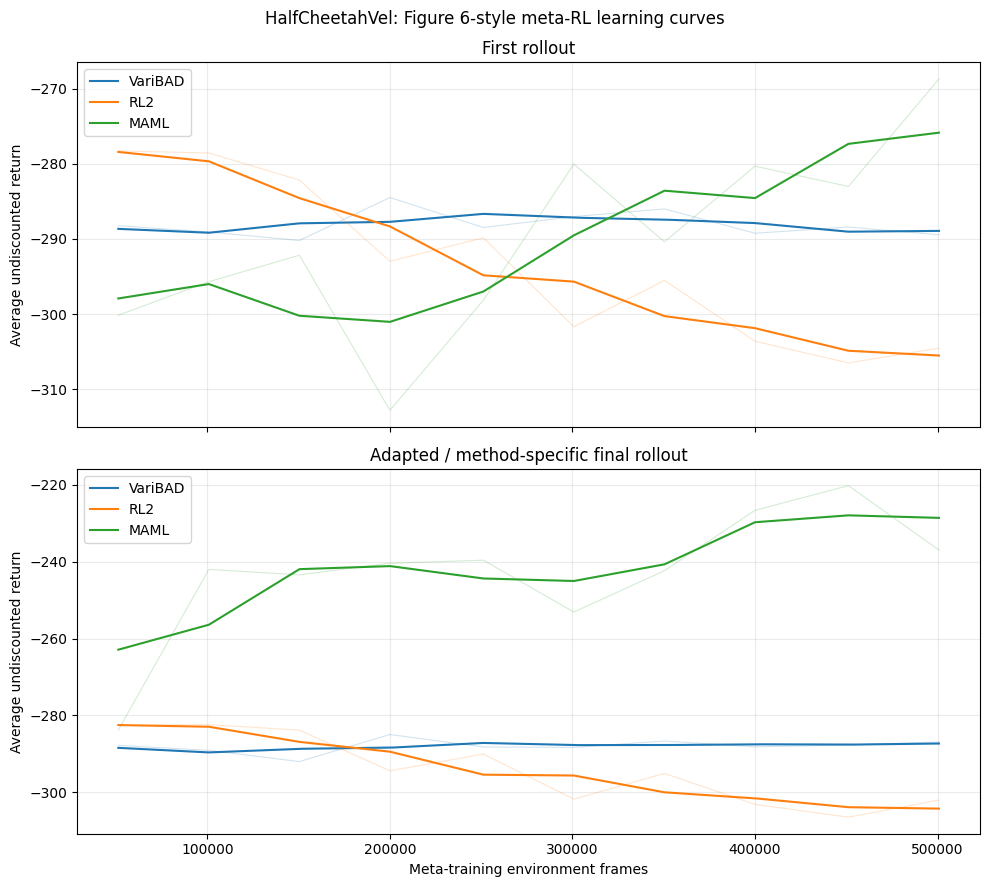

,method,seeds,final_frames_mean,first_rollout_mean,first_rollout_std,adapted_mean,adapted_std,mean_adaptation_gain
2,MAML,1,500800.0,-280.501320,0.0,-235.843139,0.0,44.658181
0,VariBAD,1,500800.0,-288.036108,0.0,-287.559684,0.0,0.476424
1,RL2,1,500800.0,-302.374000,0.0,-301.712000,0.0,0.662000


In [36]:
# Figure 6-style learning curves from the actual trained models.

plot_figure6_halfcheetahvel(
    all_histories,
    smoothing_window=3,
    show_individual_seeds=True,
)

final_summary = summarize_final_performance(all_histories, tail_points=5)
display(final_summary)


VariBAD (1, 10, 5) mean per rollout = [-291.35054699 -291.07058118 -290.66161504 -290.90289282 -291.34165811]
RL2 (1, 10, 5) mean per rollout = [-287.84096354 -290.54072655 -289.99283611 -289.08329186 -290.37070822]
MAML (1, 10, 5) mean per rollout = [-297.92245725 -298.97762977 -287.31378409 -299.27526866 -283.72342601]


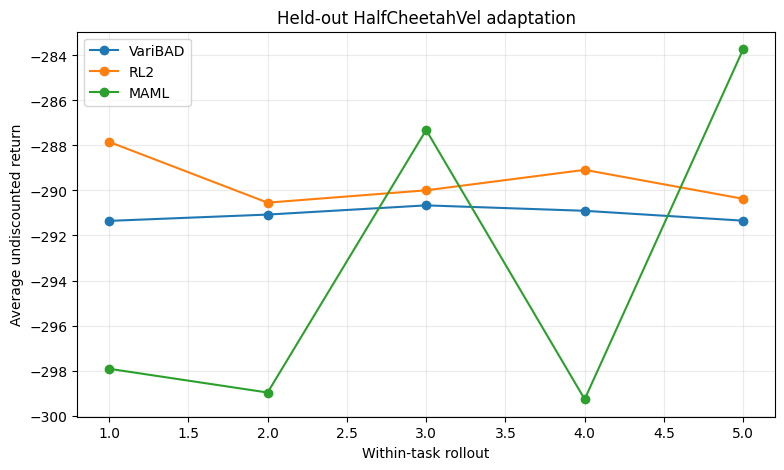

In [37]:
def collect_final_rollout_results(
    histories: Mapping[str, Sequence[Mapping[str, Any]]],
    config: ExperimentConfig,
    task_splits: TaskSplits,
    *,
    n_rollouts: int = FIGURE4_EVALUATION_ROLLOUTS,
) -> Dict[str, np.ndarray]:
    """
    Evaluate each validation-selected checkpoint on the untouched test tasks.

    Output shape for every method:
        [num_seeds, num_test_tasks, n_rollouts]
    """
    results: Dict[str, np.ndarray] = {}

    for method in ("VariBAD", "RL2", "MAML"):
        runs = histories.get(method, [])
        if not runs:
            continue

        seed_arrays = []
        for run in runs:
            agent = run.get("_agent")
            if agent is None:
                raise KeyError(
                    f"{method} history does not contain the trained '_agent' object."
                )

            env = HalfCheetahVel(
                target_velocity=float(task_splits.test[0]),
                env_id=config.env_id,
                horizon=config.episode_horizon,
            )
            try:
                task_curves = []
                for task_index, velocity in enumerate(task_splits.test):
                    env.target_velocity = float(velocity)
                    eval_rng = np.random.default_rng(
                        int(run["seed"]) * 10_000_019 + task_index
                    )
                    curve = agent.evaluate_rollouts(
                        env,
                        eval_rng,
                        n_rollouts=n_rollouts,
                    )
                    task_curves.append(curve)
                seed_arrays.append(np.stack(task_curves, axis=0))
            finally:
                env.close()

        results[method] = np.stack(seed_arrays, axis=0)

    return results


rollout_results: Dict[str, np.ndarray] = collect_final_rollout_results(
    all_histories,
    CONFIG,
    TASKS,
    n_rollouts=FIGURE4_EVALUATION_ROLLOUTS,
)

for method, values in rollout_results.items():
    print(method, values.shape, "mean per rollout =", values.mean(axis=(0, 1)))

# Additional diagnostic: all five within-task rollouts.
plot_rollout_adaptation(rollout_results)


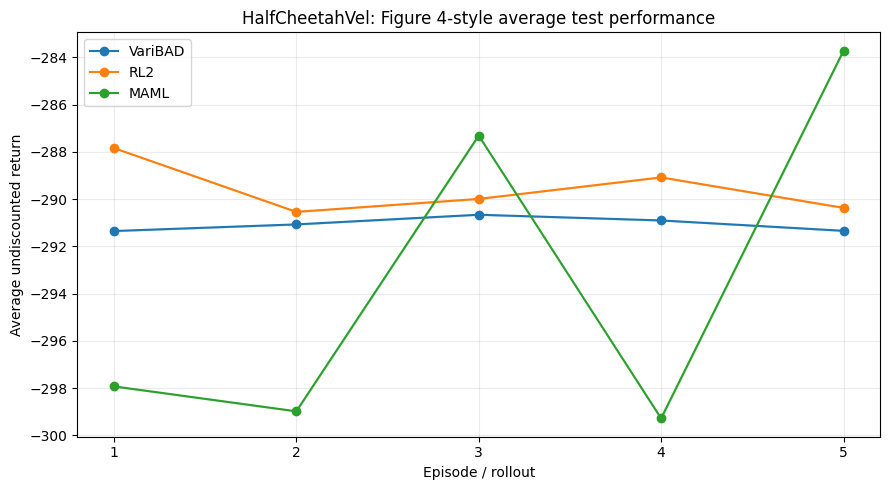

In [38]:
# Required Figure 4-style HalfCheetahVel panel.

validate_figure4_results(rollout_results)
plot_figure4_halfcheetahvel(
    rollout_results,
    show_individual_seeds=True,
)


## Question 1: Three Mechanisms for Fast Adaptation

### 1. Where is task information stored?

**MAML:** Task information is stored in the adapted policy parameters. Starting from the learned initialization, the support rollout gives a policy-gradient update:

$$
\theta'=\theta-\alpha\nabla_\theta L_{\text{support}}(\theta).
$$

For a new task, the fast parameters must be reset back to the original meta-learned parameters.

**RL²:** Task information is stored in the recurrent hidden state. The hidden state is updated from the observation, previous action, previous reward, and episode-boundary flag:

$$
h_{t+1}=f(h_t,s_t,a_{t-1},r_{t-1},d_{t-1}).
$$

The environment is reset between episodes of the same task, but the hidden state must be kept. It is reset only when a new task starts.

**VariBAD:** Task information is stored in the posterior belief over the latent task variable:

$$
q_\phi(m\mid\tau_{:t}).
$$

The encoder updates this belief after every transition. The posterior and recurrent encoder state are kept across episodes of the same task and reset to the prior for a new task.

### 2. Information gathering versus reward

During the first rollout, all methods can sacrifice some immediate reward to learn the hidden target velocity and then perform better later.

For MAML, useful experience gives a better gradient update. RL² can learn to use early rewards and transitions to change its hidden state. VariBAD directly updates a probability distribution over the hidden task.

VariBAD represents uncertainty most explicitly because it maintains a distribution with a mean and variance rather than only a parameter vector or hidden state. Its objective contains both reward reconstruction and a KL term:

$
L_{\text{VAE}}
$
==============
$
L_{\text{reconstruction}}
+
\beta D_{\mathrm{KL}}.
$

However, explicit uncertainty does not guarantee better control. The encoder, decoder, and policy must all learn useful representations. In my experiment, VariBAD had only about **+0.48** validation adaptation gain and its five-rollout test return was almost flat. Therefore, explicit uncertainty alone did not produce the best return.

MAML showed the clearest adaptation in my results, with about **+44.66** validation adaptation gain. RL² only gained about **+0.66**.

### 3. What happens if the adaptation state is accidentally reset?

For **MAML**, resetting the fast parameters between episodes removes the policy-gradient adaptation. Each new rollout would start again from the meta-initialization, so the later-rollout improvement should mostly disappear.

For **RL²**, resetting the hidden state makes the agent forget everything learned about the target velocity. Every episode would behave more like a first rollout.

For **VariBAD**, resetting the posterior and encoder state sends the task belief back to the prior. The agent loses the evidence collected in the previous episode, so later episodes should again behave like the first rollout.

Therefore, a wrong reset should make the adapted-return curve move closer to the first-rollout return. In my results I would expect the strongest visible effect for MAML, because MAML showed substantial adaptation. RL² and VariBAD already showed almost flat adaptation curves, so a reset would probably have a smaller visible effect in this particular run.
